# One-Hour-Ahead Multi-Site Solar PV Generation Forecasting

This project develops and evaluates models for forecasting solar PV generation one hour ahead across 42 PV sites. The dataset combines historical PV generation, solar irradiance, weather conditions, temporal information, and site identity.

Three forecasting approaches are evaluated:

- **Persistence**, used as a simple short-term baseline.
- **XGBoost**, using current conditions and explicitly engineered lag features.
- **LSTM**, using sequences of recent observations to learn temporal dependencies directly.

Performance is assessed with MAE, RMSE, and R² on a chronologically held-out test period. Because a large share of the dataset corresponds to zero nighttime generation, performance is also reported separately during active-generation periods.


### Dataset Source

This project uses the **UNISOLAR dataset**, which contains photovoltaic generation, solar irradiance, weather, and site information from La Trobe University's five campuses [1].




In [ ]:
# Extract the dataset archive when running in a fresh Colab session.
# Skip this command if the data folder has already been extracted.
!unzip archive.zip -d unisolar


Archive:  archive.zip
  inflating: unisolar/unisolar/Monthly_Summary_Solar.csv  
  inflating: unisolar/unisolar/Solar_Energy_Generation.csv  
  inflating: unisolar/unisolar/Solar_Site_Details.csv  
  inflating: unisolar/unisolar/Weather_Data_reordered_all.csv  
  inflating: unisolar/unisolar/Solar_Irradiance.csv  


In [ ]:
# Base directory containing the extracted UNISOLAR CSV files.
path  = 'unisolar/unisolar/'

## 0. Setup

The required Python libraries are imported below. Random seeds are used where applicable to improve reproducibility of model training.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)
from sklearn.preprocessing import (StandardScaler, OneHotEncoder)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
import tensorflow as tf
from keras import layers, Model

tf.keras.utils.set_random_seed(42)

## 1. Data Loading and Preprocessing

The source data are stored in separate tables containing PV generation, meteorological variables, solar irradiance, and site information. Preprocessing aligns timestamps, resolves differences in temporal resolution, handles missing observations, and combines the sources into a single modelling dataset.

All preprocessing is completed before model development so that XGBoost and LSTM are evaluated using a consistent underlying dataset.


In [ ]:
# Load generation, weather, irradiance, and site metadata from separate source files.
# Load data
solar  = pd.read_csv(path + 'Solar_Energy_Generation.csv')
weather = pd.read_csv(path + 'Weather_Data_reordered_all.csv')
irradiance = pd.read_csv(path + 'Solar_Irradiance.csv')
site_details =pd.read_csv(path + 'Solar_Site_Details.csv')

# Show the first 5 rows of each data
print('Solar generation data sample:\n')
display(solar.head())
print('\n\nWeather data sample\n')
display(weather.head())
print('\n\nIrradiance data sample\n')
display(irradiance.head())
print('\n\nSite details data sample\n')
display(site_details.head())


Solar generation data sample:



,CampusKey,SiteKey,Timestamp,SolarGeneration
0,2,1,2020-01-01 00:15:00,NaN
1,2,1,2020-01-01 00:30:00,NaN
2,2,1,2020-01-01 00:45:00,NaN
3,2,1,2020-01-01 01:00:00,NaN
4,2,1,2020-01-01 01:15:00,NaN




Weather data sample



,CampusKey,Timestamp,ApparentTemperature,AirTemperature,DewPointTemperature,RelativeHumidity,WindSpeed,WindDirection
0,1,2020-01-01 00:00:00,13.666667,13.880000,8.960000,72.400000,0.000000,188.133333
1,1,2020-01-01 00:15:00,13.206667,13.666667,9.040000,73.466667,1.200000,203.866667
2,1,2020-01-01 00:30:00,12.840000,13.553333,9.053333,74.000000,2.520000,222.800000
3,1,2020-01-01 00:45:00,12.113333,13.506667,9.100000,74.466667,5.986667,231.133333
4,1,2020-01-01 01:00:00,11.946667,13.260000,9.266667,76.533333,5.946667,247.866667




Irradiance data sample



,CloudOpacity,Ghi,Timestamp_UTC,Campus
0,15.5,823,2019-12-31 00:00:00,Bundoora
1,0.0,1063,2019-12-31 01:00:00,Bundoora
2,0.0,1090,2019-12-31 02:00:00,Bundoora
3,0.0,1049,2019-12-31 03:00:00,Bundoora
4,0.0,948,2019-12-31 04:00:00,Bundoora




Site details data sample



,CampusKey,SiteKey,kWp,Number of panels,Panel,Inverter,Optimizers,Metric,lat,Lon
0,2,1,NaN,NaN,NaN,NaN,NaN,NaN,-36.111209,146.848679
1,2,2,NaN,NaN,NaN,NaN,NaN,NaN,-36.111209,146.848679
2,2,3,NaN,NaN,NaN,NaN,NaN,NaN,-36.111209,146.848679
3,2,4,NaN,NaN,NaN,NaN,NaN,NaN,-36.111209,146.848679
4,2,5,NaN,NaN,NaN,NaN,NaN,NaN,-36.111209,146.848679


In [ ]:
# Parse timestamps before any timezone conversion, resampling, or temporal joins.
#converting timestamps to datetime objects
solar['Timestamp'] = pd.to_datetime(solar['Timestamp'])
weather['Timestamp'] = pd.to_datetime(weather['Timestamp'])
irradiance['Timestamp_UTC'] = pd.to_datetime(irradiance['Timestamp_UTC'])


### 1.1 Irradiance Data

The irradiance dataset contains hourly GHI and cloud-opacity observations recorded in UTC, whereas the generation and weather datasets use local Australian time. Irradiance timestamps are therefore converted to the `Australia/Melbourne` timezone.

The conversion can create repeated local timestamps around daylight-saving transitions. These duplicate observations are aggregated to obtain one record per campus and timestamp. Because PV generation is recorded every 15 minutes, the hourly irradiance series is subsequently resampled to 15-minute resolution using time-based interpolation.


In [ ]:
# check for missing values
irradiance.isna().sum()

,0
CloudOpacity,0
Ghi,0
Timestamp_UTC,0
Campus,0


In [ ]:
# check for duplicates
irradiance.duplicated(subset=['Timestamp_UTC','Campus']).sum()

np.int64(0)

Initial checks found no missing values or duplicate `(Timestamp_UTC, Campus)` observations in the irradiance data.


The irradiance timestamps are converted from UTC to local Australian time so that they can be aligned with the solar-generation and weather observations.


In [ ]:
# Convert UTC irradiance times to local Melbourne time before merging with local datasets.
#converting irradiance data timestamp from UTC to Australian time
irradiance['Timestamp'] = irradiance['Timestamp_UTC'].dt.tz_localize('UTC').dt.tz_convert('Australia/Melbourne').dt.tz_localize(None)
irradiance.head()


,CloudOpacity,Ghi,Timestamp_UTC,Campus,Timestamp
0,15.5,823,2019-12-31 00:00:00,Bundoora,2019-12-31 11:00:00
1,0.0,1063,2019-12-31 01:00:00,Bundoora,2019-12-31 12:00:00
2,0.0,1090,2019-12-31 02:00:00,Bundoora,2019-12-31 13:00:00
3,0.0,1049,2019-12-31 03:00:00,Bundoora,2019-12-31 14:00:00
4,0.0,948,2019-12-31 04:00:00,Bundoora,2019-12-31 15:00:00


In [ ]:
# check for duplicates
irradiance.duplicated(subset=['Timestamp','Campus']).sum()

np.int64(15)

In [ ]:
# duplicates
irradiance[irradiance.duplicated(subset=['Timestamp','Campus'], keep=False)]

,CloudOpacity,Ghi,Timestamp_UTC,Campus,Timestamp
2295,0.0,0,2020-04-04 15:00:00,Bundoora,2020-04-05 02:00:00
2296,0.0,0,2020-04-04 16:00:00,Bundoora,2020-04-05 02:00:00
11031,0.0,0,2021-04-03 15:00:00,Bundoora,2021-04-04 02:00:00
11032,0.0,0,2021-04-03 16:00:00,Bundoora,2021-04-04 02:00:00
19767,55.8,0,2022-04-02 15:00:00,Bundoora,2022-04-03 02:00:00
19768,44.1,0,2022-04-02 16:00:00,Bundoora,2022-04-03 02:00:00
22767,0.0,0,2020-04-04 15:00:00,Bendigo,2020-04-05 02:00:00
22768,0.0,0,2020-04-04 16:00:00,Bendigo,2020-04-05 02:00:00
31503,0.0,0,2021-04-03 15:00:00,Bendigo,2021-04-04 02:00:00
31504,0.0,0,2021-04-03 16:00:00,Bendigo,2021-04-04 02:00:00


Duplicate local timestamps introduced by the daylight-saving conversion are aggregated by campus and timestamp. GHI and cloud opacity are averaged to obtain one representative observation for each duplicated time.


In [ ]:
# Average duplicate local timestamps created around daylight-saving transitions.
# Aggregating duplicate timestamps
irradiance = (irradiance
    .groupby(['Campus', 'Timestamp'], as_index=False)
    .agg({'CloudOpacity': 'mean','Ghi':'mean'})
)

irradiance.duplicated(subset=['Timestamp','Campus']).sum()


np.int64(0)

#### Campus Mapping

The irradiance table identifies campuses by name, while the generation and weather datasets use numeric `CampusKey` values. Campus coordinates from the accompanying research paper are matched to the site coordinates so that a consistent campus identifier can be used when the datasets are merged.


In [ ]:
# Data from research paper
campus_coordinates = [['Bundoora',-37.74,145.10],
                      ['Wodonga',-36.07,146.95],
                      ['Shepparton',-36.43,145.39],
                      ['Mildura',-34.24,142.09],
                      ['Bendigo',-36.74,144.33]]

campus_coordinates = pd.DataFrame(campus_coordinates, columns=['Campus', 'Lat', 'Lon'])
campus_coordinates

,Campus,Lat,Lon
0,Bundoora,-37.74,145.10
1,Wodonga,-36.07,146.95
2,Shepparton,-36.43,145.39
3,Mildura,-34.24,142.09
4,Bendigo,-36.74,144.33


In [ ]:
campuskey_coordinates = site_details.groupby('CampusKey')[['lat', 'Lon']].first()

In [ ]:
# Reset index of campuskey_coordinates to make CampusKey a column for easier merging
campuskey_coords_df = campuskey_coordinates.reset_index()

campuskey_map = {}

# Iterate through each campus from the research paper coordinates
for index_campus, row_campus in campus_coordinates.iterrows():
    campus_name = row_campus['Campus']
    lat_campus, lon_campus = row_campus['Lat'], row_campus['Lon']

    min_distance = float('inf')
    closest_campuskey = None

    # Iterate through each CampusKey from site details coordinates
    for index_key, row_key in campuskey_coords_df.iterrows():
        campus_key = row_key['CampusKey']
        lat_key, lon_key = row_key['lat'], row_key['Lon']

        # Using Euclidean distance
        distance = ((lat_campus - lat_key)**2 + (lon_campus - lon_key)**2)**0.5

        if distance < min_distance:
            min_distance = distance
            closest_campuskey = campus_key

    campuskey_map[campus_name] = int(closest_campuskey) # Ensure int type

display(campuskey_map)


{'Bundoora': 1, 'Wodonga': 2, 'Shepparton': 5, 'Mildura': 4, 'Bendigo': 3}

In [ ]:
#mapping campus key for irradiance data
irradiance.insert(loc=0, column='CampusKey', value=irradiance['Campus'].map(campuskey_map))
irradiance.drop(columns=['Campus'], inplace=True)
irradiance.head()

,CampusKey,Timestamp,CloudOpacity,Ghi
0,3,2019-12-31 11:00:00,0.0,973.0
1,3,2019-12-31 12:00:00,0.0,1071.0
2,3,2019-12-31 13:00:00,0.0,1102.0
3,3,2019-12-31 14:00:00,0.0,1066.0
4,3,2019-12-31 15:00:00,0.0,968.0


The weather and solar-generation data are recorded at 15-minute intervals, whereas irradiance is hourly. Irradiance is therefore resampled to 15-minute resolution using time-based interpolation.


In [ ]:
# Resample hourly irradiance to the 15-minute resolution used by PV generation.
irradiance = (
    irradiance.set_index('Timestamp')
    .groupby('CampusKey', as_index=False)
    .apply(lambda group: group.resample('15min').asfreq().interpolate(method='time'))
    .reset_index()
)
irradiance['CampusKey'] = irradiance['CampusKey'].astype(int)
irradiance.drop(irradiance.columns[0], axis=1, inplace=True)
irradiance.head()


/tmp/ipykernel_687/1272720732.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.resample('15min').asfreq().interpolate(method='time'))


,Timestamp,CampusKey,CloudOpacity,Ghi
0,2019-12-31 11:00:00,1,15.500,823.0
1,2019-12-31 11:15:00,1,11.625,883.0
2,2019-12-31 11:30:00,1,7.750,943.0
3,2019-12-31 11:45:00,1,3.875,1003.0
4,2019-12-31 12:00:00,1,0.000,1063.0


### 1.2 Weather Data

Weather observations are checked for duplicate timestamps and missing values before imputation. The goal is to fill only short, plausible gaps while avoiding extensive interpolation across long missing periods.


In [ ]:
#check for duplicates
weather.duplicated(subset=['Timestamp','CampusKey']).sum()

np.int64(0)

In [ ]:
#check for missing values
display(weather.isna().sum()) #as count
display(weather.isna().mean().mul(100).round(2)) #as percentage

,0
CampusKey,0
Timestamp,0
ApparentTemperature,107113
AirTemperature,107113
DewPointTemperature,107113
RelativeHumidity,107113
WindSpeed,162890
WindDirection,162890


,0
CampusKey,0.00
Timestamp,0.00
ApparentTemperature,28.81
AirTemperature,28.81
DewPointTemperature,28.81
RelativeHumidity,28.81
WindSpeed,43.81
WindDirection,43.81


Apparent temperature, air temperature, dew-point temperature, and relative humidity share the same missing timestamps, indicating a common gap pattern across these variables.


In [ ]:
# Identify the length of consecutive missing temperature/humidity gaps within each campus.
# find consecutive missing gaps
weather = weather.sort_values(['CampusKey', 'Timestamp'])
weather['Missing'] = weather[['ApparentTemperature','AirTemperature','DewPointTemperature','RelativeHumidity']].isna().any(axis=1)
gap_summary = []

for campus, group in weather.groupby('CampusKey'):

    group = group.sort_values('Timestamp').copy()

    # Create groups whenever Missing changes True/False
    group['Gap_ID'] = (group['Missing'] != group['Missing'].shift()).cumsum()

    # Keep only missing groups
    gaps = (
        group[group['Missing']]
        .groupby('Gap_ID')
        .agg(
            Start=('Timestamp', 'first'),
            End=('Timestamp', 'last'),
            Length=('Timestamp', 'size')
        )
        .reset_index(drop=True)
    )

    gaps['CampusKey'] = campus

    gap_summary.append(gaps)

gap_summary = pd.concat(gap_summary, ignore_index=True)


In [ ]:
# Distribution of gap lengths
gap_distribution = (
    gap_summary['Length']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

display(gap_summary['Length'].value_counts().sort_index()) #count
display(gap_distribution) #percentage

,count
Length,
1,53521
3,25
4,6
5,2
7,1
9,1
15,1
40,3
41,1


,proportion
Length,
1,99.92
3,0.05
4,0.01
5,0.00
7,0.00
9,0.00
15,0.00
40,0.01
41,0.00


More than 99.9% of missing temperature and humidity sequences are isolated 15-minute gaps. Gaps of up to four consecutive observations (one hour) are therefore filled using time-based interpolation within each campus.


In [ ]:
# Interpolate only short weather gaps (maximum four 15-minute observations = one hour).
weather = (
    weather
    .set_index('Timestamp')
    .groupby('CampusKey', as_index=False)
    .apply(
        lambda x: x.interpolate(
            method='time',
            limit=4,                # Fill at most 4 consecutive NaNs
            limit_direction='both'
        )
    )
    .reset_index()
)
weather.drop(weather.columns[[0,-1]], axis=1, inplace=True)


/tmp/ipykernel_687/1724584300.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


Wind speed and wind direction also share the same missing timestamps, but their missing sequences are longer than those of the temperature and humidity variables.


In [ ]:
# find consecutive missing gaps
weather = weather.sort_values(['CampusKey', 'Timestamp'])
weather['Missing'] = weather[['WindSpeed','WindDirection']].isna().any(axis=1)
gap_summary = []

for campus, group in weather.groupby('CampusKey'):

    group = group.sort_values('Timestamp').copy()

    # Create groups whenever Missing changes True/False
    group['Gap_ID'] = (group['Missing'] != group['Missing'].shift()).cumsum()

    # Keep only missing groups
    gaps = (
        group[group['Missing']]
        .groupby('Gap_ID')
        .agg(
            Start=('Timestamp', 'first'),
            End=('Timestamp', 'last'),
            Length=('Timestamp', 'size')
        )
        .reset_index(drop=True)
    )

    gaps['CampusKey'] = campus

    gap_summary.append(gaps)

weather.drop(columns=['Missing'], inplace=True)

gap_summary = pd.concat(gap_summary, ignore_index=True)

gap_summary['Length'].value_counts().sort_index()

,count
Length,
32,3
1088,1
17826,1
25994,1
28586,1
44614,2


Because wind variables contain longer gaps that would require substantial interpolation, they are excluded from the modelling dataset. Remaining rows with missing temperature or humidity values are removed after short-gap interpolation.


In [ ]:
# Wind variables are excluded because their longer gaps would require extensive imputation.
# Dropping columns (WindSpeed, WindDirection) and rows with nan
weather.drop(columns=['WindSpeed','WindDirection'], inplace=True)
weather.dropna(subset=['ApparentTemperature','AirTemperature','DewPointTemperature','RelativeHumidity'], inplace=True)


In [ ]:
weather.isna().sum()

,0
Timestamp,0
CampusKey,0
ApparentTemperature,0
AirTemperature,0
DewPointTemperature,0
RelativeHumidity,0


### 1.3 Solar Generation Data

Solar generation contains substantial missing data, including observations during periods when PV production is physically expected to be zero. Irradiance information is used to distinguish likely non-generating periods from missing measurements during active generation.

Missing generation observations corresponding to zero GHI are assigned zero. A site-specific low-irradiance threshold is then used to identify additional low-light periods where missing generation can reasonably be treated as zero. Only short remaining gaps are interpolated; longer gaps are removed rather than synthesizing extended generation profiles.


In [ ]:
#check for duplicates
solar.duplicated(subset=['Timestamp','SiteKey']).sum()

np.int64(0)

In [ ]:
#check for missing values
display(solar.isna().sum()) #as count
display(solar.isna().mean().mul(100).round(2)) #as percentage

,0
CampusKey,0
SiteKey,0
Timestamp,0
SolarGeneration,1536301


,0
CampusKey,0.00
SiteKey,0.00
Timestamp,0.00
SolarGeneration,56.23


In [ ]:
# Add irradiance to the generation table so missing PV values can be assessed using GHI.
# Merge solar and irradiance data
solar_irr = solar.merge(irradiance, on=['Timestamp','CampusKey'], how='left')
solar_irr.head()


,CampusKey,SiteKey,Timestamp,SolarGeneration,CloudOpacity,Ghi
0,2,1,2020-01-01 00:15:00,NaN,0.0,0.0
1,2,1,2020-01-01 00:30:00,NaN,0.0,0.0
2,2,1,2020-01-01 00:45:00,NaN,0.0,0.0
3,2,1,2020-01-01 01:00:00,NaN,0.0,0.0
4,2,1,2020-01-01 01:15:00,NaN,0.0,0.0


In [ ]:
# When GHI is zero, missing PV output is physically consistent with zero generation.
# Ghi = 0, solar generation = 0
solar_irr.loc[(solar_irr['Ghi'] == 0) & (solar_irr['SolarGeneration'].isna()), 'SolarGeneration'] = 0
solar_irr.loc[(solar_irr['Ghi'] == 0) & (solar_irr['SolarGeneration'] > 0), 'SolarGeneration'] = 0

display(solar_irr.isna().sum()) # as count
display(solar_irr.isna().mean().mul(100).round(2)) # as percentage


,0
CampusKey,0
SiteKey,0
Timestamp,0
SolarGeneration,351976
CloudOpacity,0
Ghi,0


,0
CampusKey,0.00
SiteKey,0.00
Timestamp,0.00
SolarGeneration,12.88
CloudOpacity,0.00
Ghi,0.00


In [ ]:
# Estimate a site-specific low-light threshold from GHI observed during active generation.
def quantile_threshold(df):
  df = df.copy().sort_index()

  # Calculate the 10th percentile threshold

  # Filter for rows where generation is active
  active_ghi = df.loc[df['SolarGeneration'] > 0, 'Ghi']


  # The 10th percentile: Missing generation at or below this threshold is treated as zero.
  threshold = active_ghi.quantile(0.1)

  df.loc[(df['Ghi'] <= threshold) & (df['SolarGeneration'].isna()), 'SolarGeneration'] = 0

  return df


In [ ]:
solar_irr = solar_irr.groupby('SiteKey',group_keys=False).apply(quantile_threshold)

/tmp/ipykernel_687/3757588203.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  solar_irr = solar_irr.groupby('SiteKey',group_keys=False).apply(quantile_threshold)


In [ ]:
# Inspect the lengths of remaining generation gaps before deciding what can be interpolated.
# find consecutive missing gaps
solar_irr = solar_irr.sort_values(['SiteKey', 'Timestamp'])
solar_irr['Missing'] = solar_irr['SolarGeneration'].isna()
gap_summary = []

for site, group in solar_irr.groupby('SiteKey'):

    group = group.sort_values('Timestamp').copy()

    # Create groups whenever Missing changes True/False
    group['Gap_ID'] = (group['Missing'] != group['Missing'].shift()).cumsum()

    # Keep only missing groups
    gaps = (
        group[group['Missing']]
        .groupby('Gap_ID')
        .agg(
            Start=('Timestamp', 'first'),
            End=('Timestamp', 'last'),
            Length=('Timestamp', 'size')
        )
        .reset_index(drop=True)
    )

    gaps['SiteKey'] = site

    gap_summary.append(gaps)

solar_irr.drop(columns=['Missing'], inplace=True)

gap_summary = pd.concat(gap_summary, ignore_index=True)


In [ ]:
# Distribution of gap lengths
gap_distribution = (
    gap_summary['Length']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

display(gap_summary['Length'].value_counts().sort_index().head(10)) #count
display(gap_distribution.head(10)) #percentage

,count
Length,
1,18888
2,17781
3,3467
4,1340
5,910
6,642
7,526
8,409
9,352


,proportion
Length,
1,40.70
2,38.31
3,7.47
4,2.89
5,1.96
6,1.38
7,1.13
8,0.88
9,0.76


In [ ]:
# Interpolate only short internal generation gaps; long gaps are left missing and removed later.
# 1. Identify NaNs in SolarGeneration
is_nan = solar_irr['SolarGeneration'].isna()

# 2. Count consecutive NaNs within each SiteKey
gap_sizes = (
    is_nan
    .groupby([
        solar_irr['SiteKey'],
        (~is_nan).groupby(solar_irr['SiteKey']).cumsum()
    ])
    .transform('sum')
)

# 3. Interpolate within each SiteKey
interpolated = (
    solar_irr.groupby('SiteKey')['SolarGeneration']
         .transform(lambda x: x.interpolate(method='linear'))
)

# 4. Fill only gaps of length 2 or less
solar_irr['SolarGeneration'] = solar_irr['SolarGeneration'].fillna(
    interpolated.where(gap_sizes <= 2)
)


In [ ]:
solar_irr.dropna(inplace=True)

In [ ]:
# Merge the cleaned generation/irradiance table with weather observations.
# Merge with weather data
final_df = solar_irr.merge(weather, on=['Timestamp','CampusKey'], how='inner')
final_df.head()


,CampusKey,SiteKey,Timestamp,SolarGeneration,CloudOpacity,Ghi,ApparentTemperature,AirTemperature,DewPointTemperature,RelativeHumidity
0,2,1,2020-01-01 00:15:00,0.0,0.0,0.0,18.560000,20.300000,9.600000,50.266667
1,2,1,2020-01-01 00:30:00,0.0,0.0,0.0,18.146667,19.840000,9.340000,50.666667
2,2,1,2020-01-01 00:45:00,0.0,0.0,0.0,18.140000,19.886667,9.486667,51.000000
3,2,1,2020-01-01 01:00:00,0.0,0.0,0.0,17.693333,19.540000,9.180000,51.133333
4,2,1,2020-01-01 01:15:00,0.0,0.0,0.0,17.613333,19.153333,9.053333,51.933333


## 2. Exploratory Data Analysis

Exploratory analysis examines the physical plausibility of the cleaned data, differences in generation scale between sites, daily and seasonal PV patterns, and relationships between generation and meteorological variables.

Because the 42 PV installations operate at substantially different generation scales, site-level distributions and normalized generation are used where appropriate rather than relying only on pooled values.


### 2.3 Physical Plausibility and Site-Level Distributions

The cleaned variables are checked against physically reasonable ranges. Site-specific generation statistics and boxplots are then used to determine whether large values represent genuine high-output sites rather than corrupted observations.


In [ ]:
columns = [
    'SolarGeneration',
    'Ghi',
    'CloudOpacity',
    'ApparentTemperature',
    'AirTemperature',
    'DewPointTemperature',
    'RelativeHumidity'
]

final_df[columns].describe(
    percentiles=[
        0.001, 0.01, 0.05,
        0.25, 0.5, 0.75,
        0.95, 0.99, 0.999
    ]
).T


,count,mean,std,min,0.1%,1%,5%,25%,50%,75%,95%,99%,99.9%,max
SolarGeneration,2569203.0,3.270510,8.513403,0.000000,0.000000,0.00,0.000000,0.000000,0.000000,2.888672,14.937500,46.5625,85.875000,99.218800
Ghi,2569203.0,181.723179,266.740186,0.000000,0.000000,0.00,0.000000,0.000000,12.500000,301.000000,791.000000,987.0000,1067.000000,1128.000000
CloudOpacity,2569203.0,26.696276,27.491514,0.000000,0.000000,0.00,0.000000,0.175000,18.300000,47.800000,79.100000,90.7000,95.400000,97.000000
ApparentTemperature,2569203.0,13.391820,6.961702,-6.633333,-3.133333,-0.22,3.240000,8.346667,12.500000,17.900000,26.333333,31.0000,34.700000,41.586667
AirTemperature,2569203.0,15.286057,6.518047,-2.706667,-0.131987,2.32,5.746667,10.760000,14.500000,19.080000,27.733333,32.7500,37.506667,45.400000
DewPointTemperature,2569203.0,9.489448,4.144429,-11.473333,-1.986667,1.00,3.213333,6.500000,9.166667,12.246667,16.900000,19.5000,21.700000,25.320000
RelativeHumidity,2569203.0,72.778121,21.875877,3.066667,11.266667,21.00,33.800000,56.533333,74.200000,93.866667,100.000000,100.0000,100.000000,100.000000


In [ ]:
site_stats = (
    final_df.groupby('SiteKey')['SolarGeneration']
    .agg(
        count='count',
        mean='mean',
        p95=lambda x: x.quantile(0.95),
        p99=lambda x: x.quantile(0.99),
        p999=lambda x: x.quantile(0.999),
        max='max'
    )
)

site_stats

,count,mean,p95,p99,p999,max
SiteKey,,,,,,
1,77979,4.397047,18.812500,21.062500,21.687500,21.778000
2,77591,3.686095,16.401000,18.218750,18.531250,18.562500
3,77978,2.662573,11.625000,13.062500,13.375000,13.406250
4,45898,0.388493,1.695312,1.898438,1.996094,1.996094
5,44378,0.375163,1.695312,1.902344,2.000000,2.000000
6,41442,5.382758,24.062109,27.906250,28.656250,28.734375
7,64166,1.997655,11.968700,15.218750,15.937500,16.031250
8,41434,5.004771,23.198047,26.234375,26.888370,26.968750
9,74249,0.403393,1.757812,1.992188,2.011719,2.011719


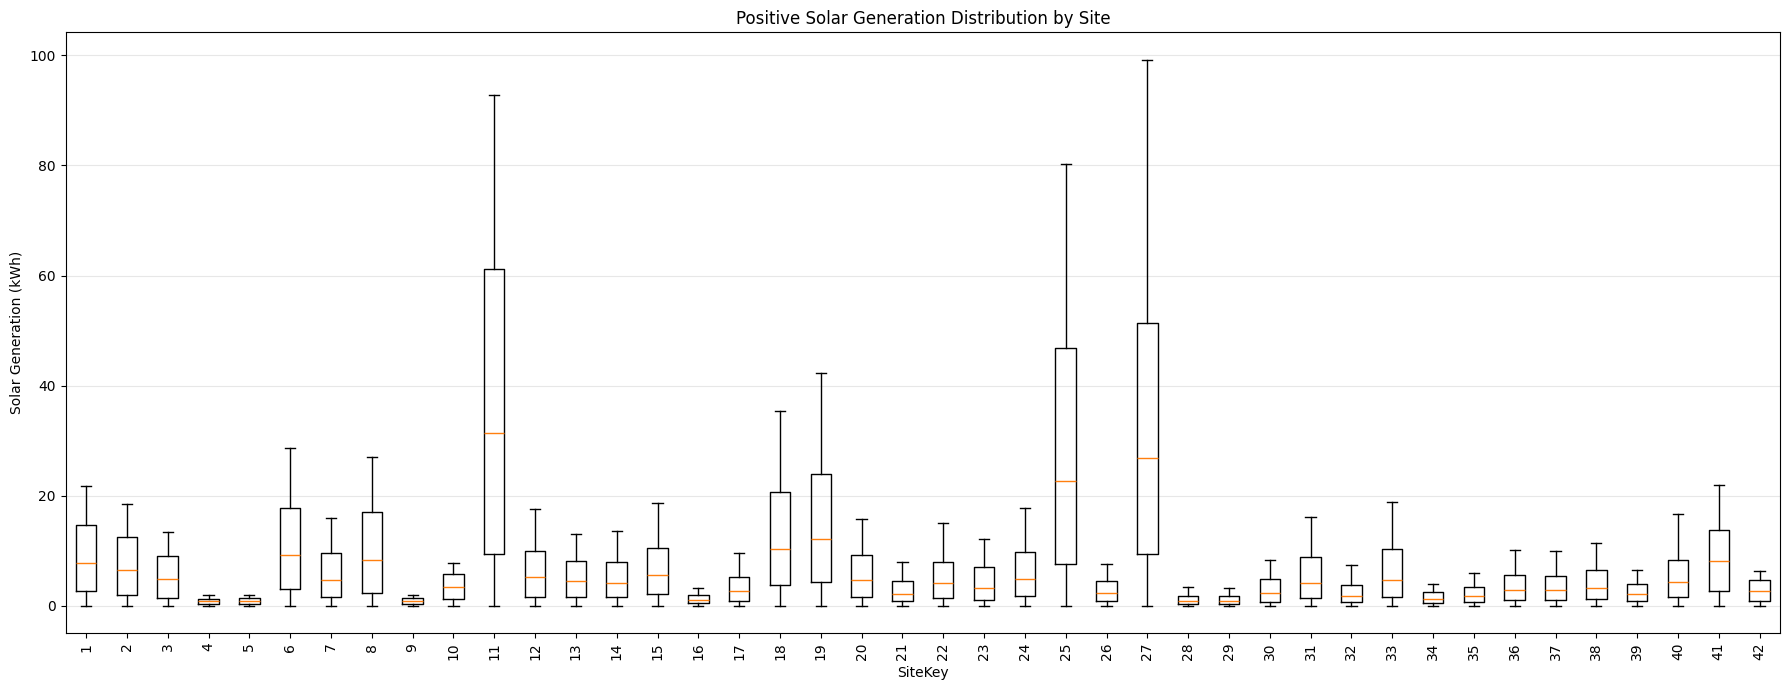

In [ ]:
# Keep only periods with positive solar generation
solar_positive = final_df[
    final_df['SolarGeneration'] > 0
].copy()

site_key = sorted(solar_positive['SiteKey'].unique())

site_data = [
    solar_positive.loc[
        solar_positive['SiteKey'] == site,
        'SolarGeneration'
    ].dropna().values
    for site in site_key
]

plt.figure(figsize=(18, 7))

plt.boxplot(
    site_data,
    tick_labels=site_key,
    showfliers=True
)

plt.xlabel('SiteKey')
plt.ylabel('Solar Generation (kWh)')
plt.title('Positive Solar Generation Distribution by Site')

plt.xticks(rotation=90)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

The numerical ranges, physical limits, site-specific upper percentiles, and positive-generation boxplots show no evidence of anomalous extreme values that require removal. Large generation values are consistent with the operating ranges of individual sites and are therefore retained.


### 2.4 Generation Scale and Active Periods

Generation is normalized by each site's observed maximum so that sites with different operating scales can be compared. The proportion of zero and positive generation is also quantified because nighttime zeros can make overall forecasting metrics appear stronger than daytime performance.


In [ ]:
# Normalize by each site's observed maximum to make differently sized installations comparable.
max_generation_per_site = final_df.groupby('SiteKey')['SolarGeneration'].max()
final_df['NormalisedGeneration'] = final_df.apply(
    lambda row: row['SolarGeneration'] / max_generation_per_site[row['SiteKey']]
    if max_generation_per_site[row['SiteKey']] > 0 else 0, axis=1
)


In [ ]:
zero_pct = (final_df['SolarGeneration'] == 0).mean() * 100
positive_pct = (final_df['SolarGeneration'] > 0).mean() * 100


print(f'Zero generation: {zero_pct:.2f}%')
print(f'Positive generation: {positive_pct:.2f}%')

### 2.1 Relationship Between Irradiance and PV Generation

PV generation is normalized by each site's maximum observed generation before plotting against GHI. This makes the relationship easier to compare across installations with very different generation scales.


In [ ]:
sample = final_df.sample(
    n=100_000,
    random_state=42
)

plt.figure(figsize=(9, 6))

plt.scatter(
    sample['Ghi'],
    sample['NormalisedGeneration'],
    alpha=0.15,
    s=5
)

plt.xlabel('GHI (kWh/m²)')
plt.ylabel('Normalised Solar Generation')
plt.title('Normalised Solar Generation vs GHI')

plt.show()

### 2.2 Daily and Seasonal PV Profiles

The average intraday profile is examined to confirm the expected daylight generation cycle. Monthly averages are also used to inspect seasonal variation over the study period.


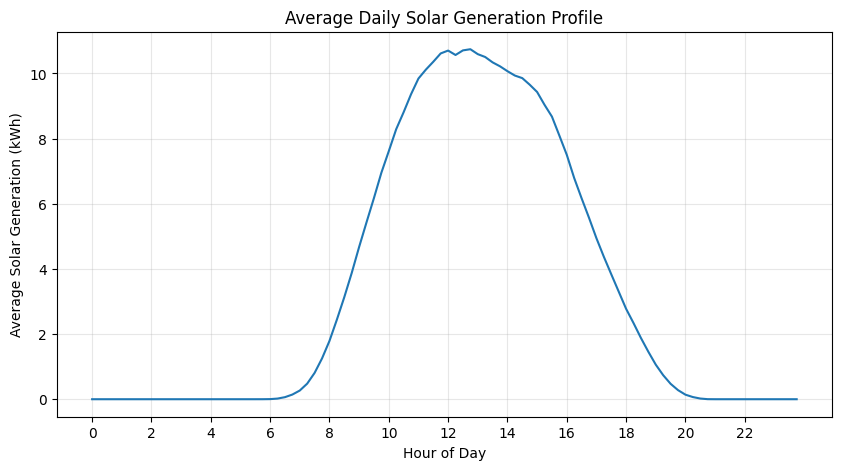

In [ ]:
final_df['Hour'] = (
    final_df['Timestamp'].dt.hour +
    final_df['Timestamp'].dt.minute / 60
)

daily_profile = (
    final_df.groupby('Hour')['SolarGeneration']
    .mean()
)

plt.figure(figsize=(10, 5))

plt.plot(
    daily_profile.index,
    daily_profile.values
)

plt.xlabel('Hour of Day')
plt.ylabel('Average Solar Generation (kWh)')
plt.title('Average Daily Solar Generation Profile')

plt.xticks(range(0, 24, 2))
plt.grid(alpha=0.3)

plt.show()

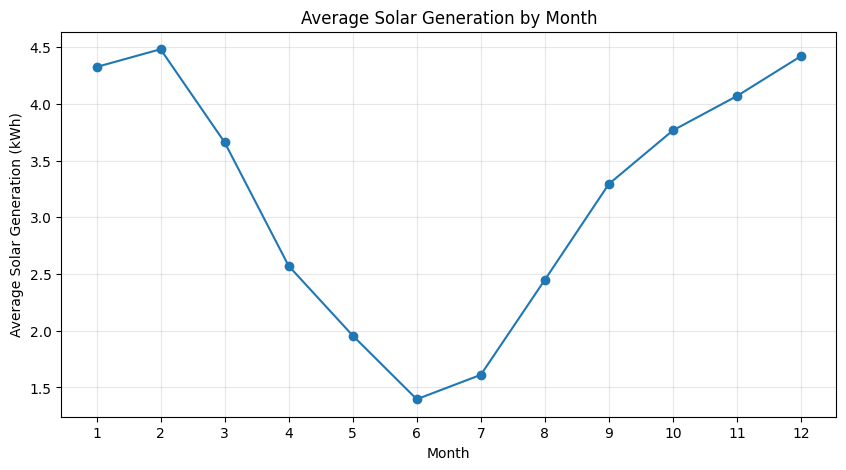

In [ ]:
final_df['Month'] = final_df['Timestamp'].dt.month

monthly_profile = (
    final_df.groupby('Month')['SolarGeneration']
    .mean()
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_profile.index,
    monthly_profile.values,
    marker='o'
)

plt.xlabel('Month')
plt.ylabel('Average Solar Generation (kWh)')
plt.title('Average Solar Generation by Month')

plt.xticks(range(1, 13))
plt.grid(alpha=0.3)

plt.show()

### 2.5 Correlation With Weather Variables

The PV sites operate at substantially different generation scales, so using raw solar generation in a combined correlation analysis could cause larger installations to have a disproportionate influence on the results.

To make generation values more comparable across sites, solar generation was normalized by each site's maximum observed generation before calculating correlations with the weather variables.

The resulting correlations therefore describe the relationships between weather conditions and relative PV generation across the dataset, rather than relationships driven by differences in absolute generation capacity between sites.

In [ ]:
# Compute correlations within each site first, then average them so large sites do not dominate.
weather_var = [
    'Ghi',
    'CloudOpacity',
    'ApparentTemperature',
    'AirTemperature',
    'DewPointTemperature',
    'RelativeHumidity',
]

corr_matrix = final_df[weather_var + ['NormalisedGeneration']].corr().round(2)

corr_matrix

,Ghi,CloudOpacity,ApparentTemperature,AirTemperature,DewPointTemperature,RelativeHumidity,NormalisedGeneration
Ghi,1.00,-0.27,0.40,0.48,0.03,-0.52,0.94
CloudOpacity,-0.27,1.00,0.05,0.02,0.26,0.16,-0.23
ApparentTemperature,0.40,0.05,1.00,0.96,0.64,-0.58,0.40
AirTemperature,0.48,0.02,0.96,1.00,0.49,-0.74,0.50
DewPointTemperature,0.03,0.26,0.64,0.49,1.00,0.18,0.01
RelativeHumidity,-0.52,0.16,-0.58,-0.74,0.18,1.00,-0.56
NormalisedGeneration,0.94,-0.23,0.40,0.50,0.01,-0.56,1.00


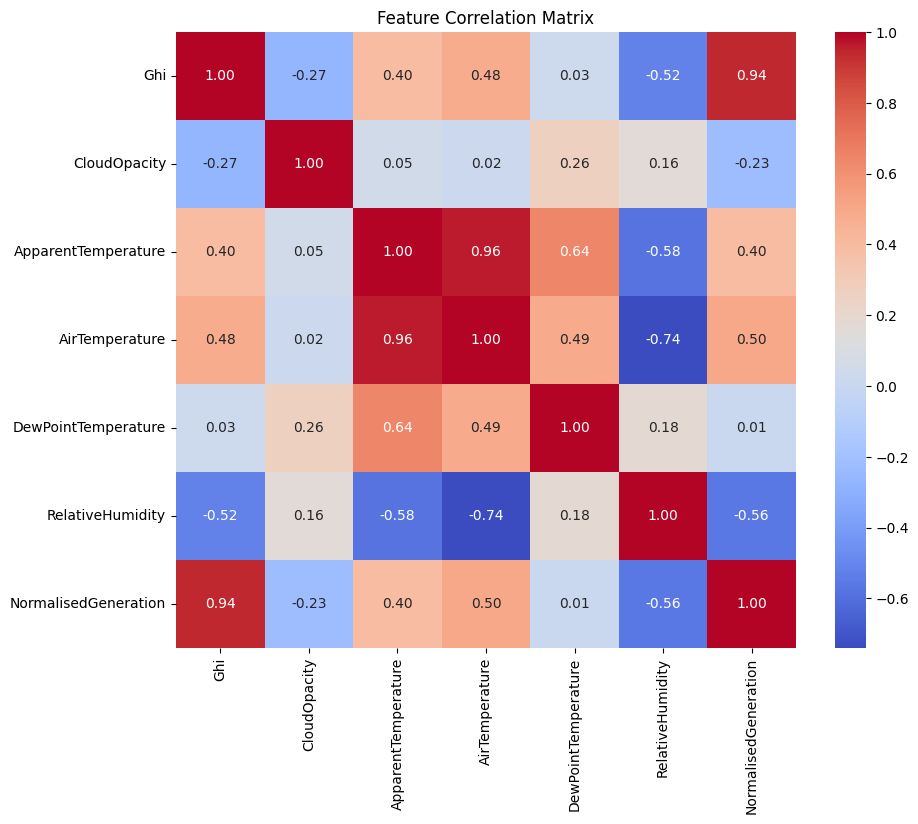

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

### 2.6 Timestamp Continuity

Before constructing forecasting targets and historical features, timestamp spacing is checked within each site. This is important because row-based shifts can produce incorrect lags when observations are missing.


In [ ]:
# Verify 15-minute continuity within each site before creating timestamp-based targets/lags.
time_diff = (
    final_df.groupby('SiteKey')['Timestamp']
         .diff()
)

time_diff.value_counts().head(10)


,count
Timestamp,
0 days 00:15:00,2559029
0 days 01:00:00,3399
0 days 01:15:00,1373
0 days 01:30:00,920
0 days 01:45:00,648
0 days 02:00:00,518
0 days 02:15:00,400
0 days 02:30:00,336
0 days 02:45:00,299


In [ ]:
print(
    '15-minute intervals:',
    (time_diff == pd.Timedelta(minutes=15)).sum()
)

print(
    'Other intervals:',
    (
        time_diff.notna() &
        (time_diff != pd.Timedelta(minutes=15))
    ).sum()
)

15-minute intervals: 2559029
Other intervals: 10132


## 3. Forecasting Problem and Feature Engineering

The objective is to predict PV generation exactly **one hour ahead**. For an observation at time *t*, the target is generation at *t + 1 hour* for the same site.

The target is created using timestamp matching rather than a simple row shift. This ensures that a target is assigned only when an observation exists exactly one hour later, even when gaps occur in the time series.


In [ ]:
# Match on the exact timestamp one hour ahead instead of using shift(-4), which can fail across gaps.
# Create target

final_df['TargetTimestamp'] = (
    final_df['Timestamp'] + pd.Timedelta(hours=1)
)

future_generation = final_df[
    ['SiteKey', 'Timestamp', 'SolarGeneration']
].copy()

future_generation = future_generation.rename(
    columns={
        'Timestamp': 'TargetTimestamp',
        'SolarGeneration': 'Target_1h'
    }
)

final_df = final_df.merge(
    future_generation,
    on=['SiteKey', 'TargetTimestamp'],
    how='left'
)

final_df[
    ['SiteKey', 'Timestamp', 'SolarGeneration',
     'TargetTimestamp', 'Target_1h']
].head(10)


,SiteKey,Timestamp,SolarGeneration,TargetTimestamp,Target_1h
0,1,2020-01-01 00:15:00,0.0,2020-01-01 01:15:00,0.0
1,1,2020-01-01 00:30:00,0.0,2020-01-01 01:30:00,0.0
2,1,2020-01-01 00:45:00,0.0,2020-01-01 01:45:00,0.0
3,1,2020-01-01 01:00:00,0.0,2020-01-01 02:00:00,0.0
4,1,2020-01-01 01:15:00,0.0,2020-01-01 02:15:00,0.0
5,1,2020-01-01 01:30:00,0.0,2020-01-01 02:30:00,0.0
6,1,2020-01-01 01:45:00,0.0,2020-01-01 02:45:00,0.0
7,1,2020-01-01 02:00:00,0.0,2020-01-01 03:00:00,0.0
8,1,2020-01-01 02:15:00,0.0,2020-01-01 03:15:00,0.0
9,1,2020-01-01 02:30:00,0.0,2020-01-01 03:30:00,0.0


In [ ]:
print('Rows:', len(final_df))

print(
    'Valid 1-hour targets:',
    final_df['Target_1h'].notna().sum()
)

print(
    'Missing 1-hour targets:',
    final_df['Target_1h'].isna().sum()
)

Rows: 2569203
Valid 1-hour targets: 2535817
Missing 1-hour targets: 33386


In [ ]:
final_df.dropna(subset=['Target_1h'], inplace=True)

### 3.1 Cyclical Time Features

PV generation follows strong daily and seasonal cycles. Hour of day and day of year are encoded with sine and cosine transformations so that the circular nature of time is preserved—for example, times immediately before and after midnight remain close in the transformed feature space.


In [ ]:
# Cyclical encodings preserve the circular structure of daily and annual time.
# Create time features

# Postion within the year
final_df['DayOfYear'] = final_df['Timestamp'].dt.dayofyear

# Daily cycle
final_df['Hour_sin'] = np.sin(
    2 * np.pi * final_df['Hour'] / 24
)
final_df['Hour_cos'] = np.cos(
    2 * np.pi * final_df['Hour'] / 24
)

# Annual cycle
final_df['DayOfYear_sin'] = np.sin(
    2 * np.pi * final_df['DayOfYear'] / 365.25
)
final_df['DayOfYear_cos'] = np.cos(
    2 * np.pi * final_df['DayOfYear'] / 365.25
)


### 3.2 Lag Features for XGBoost

XGBoost does not inherently model sequential order. Recent PV generation and GHI are therefore supplied explicitly at 15-, 30-, and 60-minute lags. As with the forecast target, lag values are created by timestamp matching so that historical observations are used only when the exact lagged timestamp exists.


In [ ]:
xgb_data = final_df.sort_values(
    ['SiteKey', 'Timestamp']
).reset_index(drop=True).copy()

In [ ]:
# Build lag features by exact timestamp matching so missing intervals do not create false lags.
# Create lag features
lag_minutes = [15, 30, 60]

for lag in lag_minutes:

    lookup = xgb_data[
        ['SiteKey', 'Timestamp', 'SolarGeneration', 'Ghi']
    ].copy()

    lookup['Timestamp'] = (
        lookup['Timestamp'] + pd.Timedelta(minutes=lag)
    )

    lookup = lookup.rename(
        columns={
            'SolarGeneration': f'SolarGeneration_lag_{lag}m',
            'Ghi': f'Ghi_lag_{lag}m'
        }
    )

    xgb_data = xgb_data.merge(
        lookup,
        on=['SiteKey', 'Timestamp'],
        how='left',
        validate='one_to_one'
    )


In [ ]:
lag_cols = [
    'SolarGeneration_lag_15m',
    'SolarGeneration_lag_30m',
    'SolarGeneration_lag_60m',
    'Ghi_lag_15m',
    'Ghi_lag_30m',
    'Ghi_lag_60m'
]

xgb_data[lag_cols].isna().sum()

,0
SolarGeneration_lag_15m,11912
SolarGeneration_lag_30m,20268
SolarGeneration_lag_60m,30647
Ghi_lag_15m,11912
Ghi_lag_30m,20268
Ghi_lag_60m,30647


In [ ]:
features = [
    # Current state
    'SolarGeneration',
    'Ghi',
    'CloudOpacity',
    'AirTemperature',
    'DewPointTemperature',
    'RelativeHumidity',

    # Generation history
    'SolarGeneration_lag_15m',
    'SolarGeneration_lag_30m',
    'SolarGeneration_lag_60m',

    # Irradiance history
    'Ghi_lag_15m',
    'Ghi_lag_30m',
    'Ghi_lag_60m',

    # Temporal features
    'Hour_sin',
    'Hour_cos',
    'DayOfYear_sin',
    'DayOfYear_cos',

    # Site identity
    'SiteKey'
]

target = 'Target_1h'

## 4. Chronological Train, Validation, and Test Split

Because this is a forecasting task, observations are divided chronologically rather than randomly. A random split could expose the models to future information during training and produce an unrealistically optimistic evaluation.

- **Training:** before October 2021
- **Validation:** October–December 2021
- **Test:** January–April 2022

The validation set is used for model and hyperparameter selection. The test set is reserved for final evaluation.


In [ ]:
# Use chronological splits to preserve the real forecasting direction of time.
train = xgb_data[
    xgb_data['Timestamp'] < '2021-10-01'
].copy()

val = xgb_data[
    (xgb_data['Timestamp'] >= '2021-10-01') &
    (xgb_data['Timestamp'] < '2022-01-01')
].copy()

test = xgb_data[
    xgb_data['Timestamp'] >= '2022-01-01'
].copy()


In [ ]:
for name, df in [
    ('Train', train),
    ('Validation', val),
    ('Test', test)
]:
    print(
        name,
        '| rows:', len(df),
        '| sites:', df['SiteKey'].nunique(),
        '|', df['Timestamp'].min(),
        'to', df['Timestamp'].max()
    )

Train | rows: 1754741 | sites: 42 | 2020-01-01 00:15:00 to 2021-09-30 23:45:00
Validation | rows: 342690 | sites: 42 | 2021-10-01 00:00:00 to 2021-12-31 23:45:00
Test | rows: 438386 | sites: 42 | 2022-01-01 00:00:00 to 2022-04-23 21:00:00


## 5. Evaluation Framework

A common results table is used to store overall and active-generation MAE, RMSE, and R² for persistence, XGBoost, and LSTM.


In [ ]:
test_results = pd.DataFrame(
    index=['Persistence','XGBoost','LSTM'],
    columns=['MAE (Overall)', 'MAE (Active Generation)',
    'RMSE (Overall)','RMSE (Active Generation)', 'R² (Overall)','R² (Active Generation)'])
test_results

,MAE (Overall),MAE (Active Generation),RMSE (Overall),RMSE (Active Generation),R² (Overall),R² (Active Generation)
Persistence,NaN,NaN,NaN,NaN,NaN,NaN
XGBoost,NaN,NaN,NaN,NaN,NaN,NaN
LSTM,NaN,NaN,NaN,NaN,NaN,NaN


### 5.1 Persistence Baseline

Persistence assumes that generation one hour ahead will equal the current generation:

$$\hat{P}_{t+1h}=P_t$$

This provides a meaningful short-term baseline because PV output often changes gradually over short intervals. More complex models should improve on persistence to justify their additional complexity.


In [ ]:
# Persistence predicts that generation one hour ahead equals the current generation.
# Persistence baseline
persistence_test = test['SolarGeneration']
y_test = test['Target_1h']

persistence_test_mae = mean_absolute_error(
    y_test,
    persistence_test
)

persistence_test_rmse = root_mean_squared_error(
        y_test,
        persistence_test
    )

persistence_test_r2 = r2_score(
    y_test,
    persistence_test
)

print('Persistence Test Results')
print('-----------------------------------')
print(f'Persistence Test MAE:  {persistence_test_mae:.4f}')
print(f'Persistence Test RMSE: {persistence_test_rmse:.4f}')
print(f'Persistence Test R²:   {persistence_test_r2:.4f}')


Persistence Test Results
-----------------------------------
Persistence Test MAE:  1.4639
Persistence Test RMSE: 3.8214
Persistence Test R²:   0.8303


In [ ]:
test_results.loc['Persistence', 'MAE (Overall)'] = persistence_test_mae
test_results.loc['Persistence', 'RMSE (Overall)'] = persistence_test_rmse
test_results.loc['Persistence', 'R² (Overall)'] = persistence_test_r2

In [ ]:
active_mask = y_test > 0
y_test_active = y_test[active_mask]

persistence_active = persistence_test[active_mask]

persistence_active_mae = mean_absolute_error(
    y_test_active,
    persistence_active
)

persistence_active_rmse = root_mean_squared_error(
        y_test_active,
        persistence_active
    )

persistence_active_r2 = r2_score(
    y_test_active,
    persistence_active
)

print('Persistence Active-generation Test Results')
print('-----------------------------------')
print(f'Persistence Active MAE:  {persistence_active_mae:.4f}')
print(f'Persistence Active RMSE: {persistence_active_rmse:.4f}')
print(f'Persistence Active R²:   {persistence_active_r2:.4f}')

Persistence Active-generation Test Results
-----------------------------------
Persistence Active MAE:  2.8615
Persistence Active RMSE: 5.3874
Persistence Active R²:   0.7979


In [ ]:
test_results.loc['Persistence', 'MAE (Active Generation)'] = persistence_active_mae
test_results.loc['Persistence', 'RMSE (Active Generation)'] = persistence_active_rmse
test_results.loc['Persistence', 'R² (Active Generation)'] = persistence_active_r2

## 6. XGBoost Forecasting Model

XGBoost combines the current PV state, meteorological conditions, engineered historical lags, cyclical time features, and site identity. `SiteKey` is one-hot encoded so that the global model can learn systematic differences between installations without treating the numeric site identifier as an ordered quantity.


In [ ]:
# Treat SiteKey as categorical; numeric site IDs have no meaningful ordinal relationship.
X_train = train[features]
y_train = train['Target_1h']

X_val = val[features]
y_val = val['Target_1h']

categorical_features = ['SiteKey']

preprocessor = ColumnTransformer(
    transformers=[
        (
            'site',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ],
    remainder='passthrough'
)


In [ ]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

In [ ]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb_model)
])

In [ ]:
xgb_pipeline.fit(X_train, y_train)

xgb_pred = xgb_pipeline.predict(X_val)

In [ ]:
# Enforce the physical constraint that PV generation cannot be negative.
xgb_pred = np.maximum(xgb_pred, 0)

In [ ]:
xgb_mae = mean_absolute_error(y_val, xgb_pred)

xgb_rmse = root_mean_squared_error(y_val, xgb_pred)

xgb_r2 = r2_score(y_val, xgb_pred)

print(f'MAE:  {xgb_mae:.4f}')
print(f'RMSE: {xgb_rmse:.4f}')
print(f'R²:   {xgb_r2:.4f}')

MAE:  0.7665
RMSE: 2.2756
R²:   0.9495


In [ ]:
active_mask = y_val > 0

active_mae = mean_absolute_error(
    y_val[active_mask],
    xgb_pred[active_mask]
)

active_rmse = root_mean_squared_error(
        y_val[active_mask],
        xgb_pred[active_mask]
    )

active_r2 = r2_score(
    y_val[active_mask],
    xgb_pred[active_mask]
)

print('Active-generation observations:', active_mask.sum())
print(f'MAE:  {active_mae:.4f}')
print(f'RMSE: {active_rmse:.4f}')
print(f'R²:   {active_r2:.4f}')

Active-generation observations: 181765
MAE:  1.4274
RMSE: 3.1231
R²:   0.9406


### 6.1 Feature Importance

Feature importance is examined after fitting the initial XGBoost model to understand which groups of predictors contribute most strongly to the forecast.


In [ ]:
# Retrieve post-preprocessing feature names so importance values can be interpreted correctly.
feature_names = (
    xgb_pipeline
    .named_steps['preprocessor']
    .get_feature_names_out()
)

importances = (
    xgb_pipeline
    .named_steps['model']
    .feature_importances_
)

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(
    'Importance',
    ascending=False
)

feature_importance


,Feature,Importance
42,remainder__SolarGeneration,0.402182
48,remainder__SolarGeneration_lag_15m,0.251849
49,remainder__SolarGeneration_lag_30m,0.046293
54,remainder__Hour_sin,0.045043
43,remainder__Ghi,0.035751
26,site__SiteKey_27,0.032655
24,site__SiteKey_25,0.028386
18,site__SiteKey_19,0.026654
51,remainder__Ghi_lag_15m,0.016787
53,remainder__Ghi_lag_60m,0.015220


In [ ]:
site_importance = feature_importance.loc[
    feature_importance['Feature'].str.startswith('site__'),
    'Importance'
].sum()

print('Total SiteKey importance:', site_importance)

Total SiteKey importance: 0.13962683


In [ ]:
group_importance = {
    'Current Solar Generation':
        feature_importance.loc[
            feature_importance['Feature'] ==
            'remainder__SolarGeneration',
            'Importance'
        ].sum(),

    'Solar Generation History':
        feature_importance.loc[
            feature_importance['Feature'].str.contains(
                'SolarGeneration_lag'
            ),
            'Importance'
        ].sum(),

    'Current GHI':
        feature_importance.loc[
            feature_importance['Feature'] ==
            'remainder__Ghi',
            'Importance'
        ].sum(),

    'GHI History':
        feature_importance.loc[
            feature_importance['Feature'].str.contains('Ghi_lag'),
            'Importance'
        ].sum(),

    'Site':
        site_importance,

    'Time':
        feature_importance.loc[
            feature_importance['Feature'].str.contains(
                'Hour_|DayOfYear_'
            ),
            'Importance'
        ].sum(),

    'Other Weather':
        feature_importance.loc[
            feature_importance['Feature'].str.contains(
                'CloudOpacity|AirTemperature|DewPointTemperature|RelativeHumidity'
            ),
            'Importance'
        ].sum()
}

group_importance = (
    pd.Series(group_importance)
    .sort_values(ascending=False)
)

group_importance

,0
Current Solar Generation,0.402182
Solar Generation History,0.304594
Site,0.139627
Time,0.065983
GHI History,0.039555
Current GHI,0.035751
Other Weather,0.012309


### 6.2 XGBoost Feature Selection

Reduced feature sets are compared with the full model to test whether additional weather variables provide meaningful validation improvement. The aim is to retain useful predictors while avoiding unnecessary complexity.

The initial XGBoost model includes the full set of available weather predictors. To determine whether all of these variables contribute useful predictive information, reduced feature sets are compared with the full model using the validation period.

The models are evaluated using MAE, RMSE, and R². A reduced feature set would be preferred if it maintained comparable forecasting performance while eliminating unnecessary predictors.

In [ ]:
xgb_fs = pd.DataFrame({
    'Feature Set': ['Full Weather', 'Irradiance Only', 'Reduced Weather'],
    'MAE': [xgb_mae, np.nan, np.nan],
    'RMSE': [xgb_rmse, np.nan, np.nan],
    'R²': [xgb_r2, np.nan, np.nan]
})

xgb_fs.set_index('Feature Set', inplace=True)

xgb_fs

,MAE,RMSE,R²
Feature Set,,,
Full,0.766483,2.275588,0.949524
Irradiance Only,NaN,NaN,NaN
Reduced Weather,NaN,NaN,NaN


####Irradiance Only Features

In [ ]:
features_irradiance_only = [
    'SolarGeneration',
    'Ghi',

    'SolarGeneration_lag_15m',
    'SolarGeneration_lag_30m',
    'SolarGeneration_lag_60m',

    'Ghi_lag_15m',
    'Ghi_lag_30m',
    'Ghi_lag_60m',

    'Hour_sin',
    'Hour_cos',
    'DayOfYear_sin',
    'DayOfYear_cos',

    'SiteKey'
]

In [ ]:
X_train_io = train[features_irradiance_only]
X_val_io = val[features_irradiance_only]

In [ ]:
preprocessor_io = ColumnTransformer(
    transformers=[
        (
            'site',
            OneHotEncoder(handle_unknown='ignore'),
            ['SiteKey']
        )
    ],
    remainder='passthrough'
)

In [ ]:
xgb_model_io = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb_pipeline_io = Pipeline([
    ('preprocessor', preprocessor_io),
    ('model', xgb_model_io)
])

xgb_pipeline_io.fit(X_train_io, y_train)

pred_io = xgb_pipeline_io.predict(X_val_io)
pred_io = np.maximum(pred_io, 0)

In [ ]:
xgb_mae_io = mean_absolute_error(y_val, pred_io)

xgb_rmse_io = root_mean_squared_error(y_val, pred_io)

xgb_r2_io = r2_score(y_val, pred_io)

print(f'MAE:  {xgb_mae_io:.4f}')
print(f'RMSE: {xgb_rmse_io:.4f}')
print(f'R²:   {xgb_r2_io:.4f}')

MAE:  0.7790
RMSE: 2.3101
R²:   0.9480


In [ ]:
xgb_fs.loc['Irradiance Only', 'MAE'] = xgb_mae_io
xgb_fs.loc['Irradiance Only', 'RMSE'] = xgb_rmse_io
xgb_fs.loc['Irradiance Only', 'R²'] = xgb_r2_io

####Reduced Weather Features

In [ ]:
features_reduced_weather = [
    'SolarGeneration',
    'Ghi',
    'AirTemperature',
    'RelativeHumidity',

    'SolarGeneration_lag_15m',
    'SolarGeneration_lag_30m',
    'SolarGeneration_lag_60m',

    'Ghi_lag_15m',
    'Ghi_lag_30m',
    'Ghi_lag_60m',

    'Hour_sin',
    'Hour_cos',
    'DayOfYear_sin',
    'DayOfYear_cos',

    'SiteKey'
]

In [ ]:
X_train_rw = train[features_reduced_weather]
X_val_rw = val[features_reduced_weather]

preprocessor_rw = ColumnTransformer(
    transformers=[
        (
            'site',
            OneHotEncoder(handle_unknown='ignore'),
            ['SiteKey']
        )
    ],
    remainder='passthrough'
)

In [ ]:
xgb_model_rw = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb_pipeline_rw = Pipeline([
    ('preprocessor', preprocessor_rw),
    ('model', xgb_model_rw)
])

xgb_pipeline_rw.fit(X_train_rw, y_train)

pred_rw = xgb_pipeline_rw.predict(X_val_rw)
pred_rw = np.maximum(pred_rw, 0)

In [ ]:
xgb_mae_rw = mean_absolute_error(y_val, pred_rw)

xgb_rmse_rw = root_mean_squared_error(y_val, pred_rw)

xgb_r2_rw = r2_score(y_val, pred_rw)

print(f'MAE:  {xgb_mae_rw:.4f}')
print(f'RMSE: {xgb_rmse_rw:.4f}')
print(f'R²:   {xgb_r2_rw:.4f}')

MAE:  0.7867
RMSE: 2.3324
R²:   0.9470


In [ ]:
xgb_fs.loc['Reduced Weather', 'MAE'] = xgb_mae_rw
xgb_fs.loc['Reduced Weather', 'RMSE'] = xgb_rmse_rw
xgb_fs.loc['Reduced Weather', 'R²'] = xgb_r2_rw

#### Feature Selection Result

In [ ]:
xgb_fs.sort_values('RMSE')

,MAE,RMSE,R²
Feature Set,,,
Full,0.766483,2.275588,0.949524
Irradiance Only,0.778974,2.310134,0.947980
Reduced Weather,0.786717,2.332423,0.946972


The full weather feature set achieved the best validation performance, with the lowest MAE and RMSE and the highest R². Removing weather variables resulted in small but consistent reductions in forecasting accuracy.

Although the differences between the feature sets were modest, the additional weather variables did not introduce substantial model complexity for XGBoost and provided a measurable improvement in validation performance. The **full feature set was therefore retained for the final XGBoost model and subsequent hyperparameter tuning**.

### 6.3 XGBoost Hyperparameter Tuning

Hyperparameters are tuned using the validation period. The experiments examine tree depth, learning rate and number of estimators, row and feature subsampling, and minimum child weight. RMSE is treated as the primary tuning metric while MAE and R² are also monitored. The held-out test set is not used during tuning.


#### Tree Depth Selection

In [ ]:
depth_results = []

for depth in [4, 6, 8]:

    model = XGBRegressor(
        n_estimators=300,
        max_depth=depth,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    )

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)

    pred = np.maximum(
        pipeline.predict(X_val),
        0
    )

    depth_results.append({
        'max_depth': depth,
        'MAE': mean_absolute_error(y_val, pred),
        'RMSE': root_mean_squared_error(y_val, pred),
        'R²': r2_score(y_val, pred)
    })

depth_results = (
    pd.DataFrame(depth_results)
    .sort_values('RMSE')
)

depth_results

,max_depth,MAE,RMSE,R²
2,8,0.714227,2.218013,0.952046
1,6,0.766483,2.275588,0.949524
0,4,0.865014,2.421921,0.942824


Increasing the maximum tree depth improved validation performance up to a depth of 8. The model with `max_depth = 8` produced the best overall validation results among the tested depths, reducing both MAE and RMSE compared with the initial configuration.

A **maximum depth of 8 was therefore selected** for the subsequent tuning experiments.

#### Learning Rate and Number of Estimators

In [ ]:
lr_results_xgb = []

configs = [
    (0.05, 300),
    (0.10, 150),
    (0.03, 500)
]

for lr, n_est in configs:

    model = XGBRegressor(
        n_estimators=n_est,
        max_depth=8,
        learning_rate=lr,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    )

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)

    pred = np.maximum(
        pipeline.predict(X_val),
        0
    )

    lr_results_xgb.append({
        'learning_rate': lr,
        'n_estimators': n_est,
        'MAE': mean_absolute_error(y_val, pred),
        'RMSE': root_mean_squared_error(y_val, pred),
        'R²': r2_score(y_val, pred)
    })

lr_results_xgb = (
    pd.DataFrame(lr_results_xgb)
    .sort_values('RMSE')
)

lr_results_xgb

,learning_rate,n_estimators,MAE,RMSE,R²
2,0.03,500,0.714565,2.215208,0.952167
0,0.05,300,0.714227,2.218013,0.952046
1,0.10,150,0.726806,2.252778,0.950531


The two lower learning-rate configurations produced very similar validation performance. A learning rate of 0.05 with 300 estimators achieved the lowest MAE, while a learning rate of 0.03 with 500 estimators achieved the lowest RMSE and highest R².

Since RMSE was used as the primary metric for hyperparameter selection, **`learning_rate = 0.03` with `n_estimators = 500` was selected** for the subsequent tuning experiments. The higher learning-rate configuration (`0.10`) performed worse across all three evaluation metrics.

#### Row and Feature Subsampling

In [ ]:
sampling_results = []

configs = [
    (0.8, 0.8),
    (1.0, 1.0),
    (0.7, 0.8),
    (0.8, 1.0)
]

for subsample, colsample in configs:

    model = XGBRegressor(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.03,
        subsample=subsample,
        colsample_bytree=colsample,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    )

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)

    pred = np.maximum(
        pipeline.predict(X_val),
        0
    )

    sampling_results.append({
        'subsample': subsample,
        'colsample_bytree': colsample,
        'MAE': mean_absolute_error(y_val, pred),
        'RMSE': root_mean_squared_error(y_val, pred),
        'R²': r2_score(y_val, pred)
    })

sampling_results = (
    pd.DataFrame(sampling_results)
    .sort_values('RMSE')
)

sampling_results

,subsample,colsample_bytree,MAE,RMSE,R²
0,0.8,0.8,0.714565,2.215208,0.952167
2,0.7,0.8,0.716457,2.219683,0.951974
3,0.8,1.0,0.714029,2.223816,0.951795
1,1.0,1.0,0.713044,2.233356,0.951381


 Using 80% of the training observations and 80% of the available features for each tree achieved the lowest RMSE and highest R², although using all observations and features produced a slightly lower MAE.

Since RMSE was used as the primary tuning metric, **`subsample = 0.8` and `colsample_bytree = 0.8` were retained**. Subsampling also introduces additional regularization by preventing every tree from being trained on exactly the same observations and predictors.

#### Minimum Child Weight

In [ ]:
reg_results = []

for weight in [1, 5, 10]:

    model = XGBRegressor(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=weight,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    )

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)

    pred = np.maximum(
        pipeline.predict(X_val),
        0
    )

    reg_results.append({
        'min_child_weight': weight,
        'MAE': mean_absolute_error(y_val, pred),
        'RMSE': root_mean_squared_error(y_val, pred),
        'R2': r2_score(y_val, pred)
    })

reg_results = (
    pd.DataFrame(reg_results)
    .sort_values('RMSE')
)

reg_results

,min_child_weight,MAE,RMSE,R2
2,10,0.712771,2.214756,0.952187
0,1,0.714565,2.215208,0.952167
1,5,0.714446,2.219084,0.952000


The three values produced very similar validation performance. However, `min_child_weight = 10` achieved the lowest MAE and RMSE and the highest R² among the tested values.

Therefore, **`min_child_weight = 10` was selected** for the final XGBoost configuration.

#### Final XGBoost Configuration

Based on the validation experiments, the final XGBoost configuration was:

- Full predictor set
- `max_depth = 8`
- `learning_rate = 0.03`
- `n_estimators = 500`
- `subsample = 0.8`
- `colsample_bytree = 0.8`
- `min_child_weight = 10`

The selected configuration was then retrained using the combined training and validation periods before being evaluated on the held-out test set. The test set was not used during feature selection or hyperparameter tuning.

### 6.4 Final XGBoost Model

After model selection, the training and validation periods are combined and the selected XGBoost configuration is retrained. The resulting model is then evaluated on the held-out test set. Negative predictions are clipped to zero because negative PV generation is not physically meaningful.


In [ ]:
final_params = {
    'n_estimators': int(lr_results_xgb.iloc[0]['n_estimators']),
    'max_depth': int(depth_results.iloc[0]['max_depth']),
    'learning_rate': lr_results_xgb.iloc[0]['learning_rate'],
    'subsample': sampling_results.iloc[0]['subsample'],
    'colsample_bytree': sampling_results.iloc[0]['colsample_bytree'],
    'min_child_weight': int(reg_results.iloc[0]['min_child_weight']),
    'objective': 'reg:squarederror',
    'random_state': 42,
    'n_jobs': -1
}

In [ ]:
final_params

{'n_estimators': 500,
 'max_depth': 8,
 'learning_rate': np.float64(0.03),
 'subsample': np.float64(0.8),
 'colsample_bytree': np.float64(0.8),
 'min_child_weight': 10,
 'objective': 'reg:squarederror',
 'random_state': 42,
 'n_jobs': -1}

In [ ]:
# Retrain the selected XGBoost model on all pre-test observations.
train_final = pd.concat(
    [train, val],
    ignore_index=True
)

X_train_final = train_final[features]
y_train_final = train_final['Target_1h']

X_test = test[features]
y_test = test['Target_1h']


In [ ]:
final_model = XGBRegressor(**final_params)

final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', final_model)
])

final_pipeline.fit(
    X_train_final,
    y_train_final
)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('site',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['SiteKey'])])),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=np.float64(0.8), device=None,
                              early_stopping_rounds=None,
                              enable_categoric...
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None,
                              learning_rate=np.float64(0.03), max_bin=None,
                              max_cat_threshold=None, max_cat_to_onehot=None,
                              max_delta_step=None, max_depth=8, max_leaves=None,
                              min_child_weight=10, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [ ]:
# Clip physically impossible negative forecasts to zero before evaluation.
xgb_test_pred = final_pipeline.predict(X_test)

xgb_test_pred = np.maximum(xgb_test_pred, 0)

In [ ]:
xgb_test_mae = mean_absolute_error(
    y_test,
    xgb_test_pred
)

xgb_test_rmse = root_mean_squared_error(
        y_test,
        xgb_test_pred
    )

xgb_test_r2 = r2_score(
    y_test,
    xgb_test_pred
)

print('Final XGBoost Test Results')
print('-----------------------')
print(f'XGB Test MAE:  {xgb_test_mae:.4f}')
print(f'XGB Test RMSE: {xgb_test_rmse:.4f}')
print(f'XGB Test R²:   {xgb_test_r2:.4f}')

Final XGBoost Test Results
-----------------------
XGB Test MAE:  0.6156
XGB Test RMSE: 1.9867
XGB Test R²:   0.9541


In [ ]:
test_results.loc['XGBoost', 'MAE (Overall)'] = xgb_test_mae
test_results.loc['XGBoost', 'RMSE (Overall)'] = xgb_test_rmse
test_results.loc['XGBoost', 'R² (Overall)'] = xgb_test_r2

In [ ]:
active_mask = y_test > 0

y_test_active = y_test[active_mask]
pred_active = xgb_test_pred[active_mask]

xgb_active_mae = mean_absolute_error(
    y_test_active,
    pred_active
)

xgb_active_rmse = root_mean_squared_error(
        y_test_active,
        pred_active
    )

xgb_active_r2 = r2_score(
    y_test_active,
    pred_active
)

print(
    'Active-generation observations:',
    active_mask.sum()
)

print('\nXGBoost Active-generation Test Results')
print('-----------------------------------')
print(f'XGB Active MAE:  {xgb_active_mae:.4f}')
print(f'XGB Active RMSE: {xgb_active_rmse:.4f}')
print(f'XGB Active R²:   {xgb_active_r2:.4f}')

Active-generation observations: 218661

XGBoost Active-generation Test Results
-----------------------------------
XGB Active MAE:  1.2207
XGB Active RMSE: 2.8115
XGB Active R²:   0.9449


In [ ]:
test_results.loc['XGBoost', 'MAE (Active Generation)'] = xgb_active_mae
test_results.loc['XGBoost', 'RMSE (Active Generation)'] = xgb_active_rmse
test_results.loc['XGBoost', 'R² (Active Generation)'] = xgb_active_r2

### 6.5 XGBoost Site-Level Performance and Forecast Plot

Raw MAE is affected by the large differences in PV scale across sites. Site-level MAE is therefore normalized by each site's maximum observed test generation. A one-week forecast for Site 27 is also plotted to show how the model follows the daily generation profile.


In [ ]:
# Store row-level test predictions for sitewise metrics and forecast visualizations.
xgb_site_results = pd.DataFrame({
    'Timestamp': test['Timestamp'].to_numpy(),
    'SiteKey': X_test['SiteKey'].to_numpy(),
    'Actual': y_test.to_numpy(),
    'Predicted': xgb_test_pred
})

xgb_site_results['AbsoluteError'] = (
    xgb_site_results['Actual'] - xgb_site_results['Predicted']
).abs()

xgb_site_results['SquaredError'] = (
    xgb_site_results['Actual'] - xgb_site_results['Predicted']
) ** 2


In [ ]:
sitewise_xgb = (
    xgb_site_results
    .groupby('SiteKey')
    .agg(
        Observations=('Actual', 'size'),
        MAE=('AbsoluteError', 'mean'),
        MSE=('SquaredError', 'mean'),
        MeanGeneration=('Actual', 'mean'),
        MaxGeneration=('Actual', 'max')
    )
)

sitewise_xgb['RMSE'] = np.sqrt(sitewise_xgb['MSE'])

sitewise_xgb['nMAE_%'] = (
    sitewise_xgb['MAE']
    / sitewise_xgb['MaxGeneration']
    * 100
)

sitewise_xgb = sitewise_xgb.drop(columns='MSE')

sitewise_xgb.sort_values('nMAE_%', ascending=False)

,Observations,MAE,MeanGeneration,MaxGeneration,RMSE,nMAE_%
SiteKey,,,,,,
4,10466,0.125216,0.433967,1.992188,0.236447,6.285342
9,9744,0.114165,0.501577,2.011719,0.216747,5.675019
5,9092,0.105103,0.352397,2.000000,0.215080,5.255167
16,10336,0.151034,0.662585,3.308594,0.297343,4.564887
28,10339,0.147002,0.621783,3.464844,0.290337,4.242665
27,10805,3.612710,15.716671,88.625000,7.027888,4.076401
34,10572,0.162899,0.866632,4.054688,0.336494,4.017553
29,10596,0.132441,0.577100,3.304688,0.262772,4.007676
13,10523,0.515343,2.112132,12.968750,1.137492,3.973729


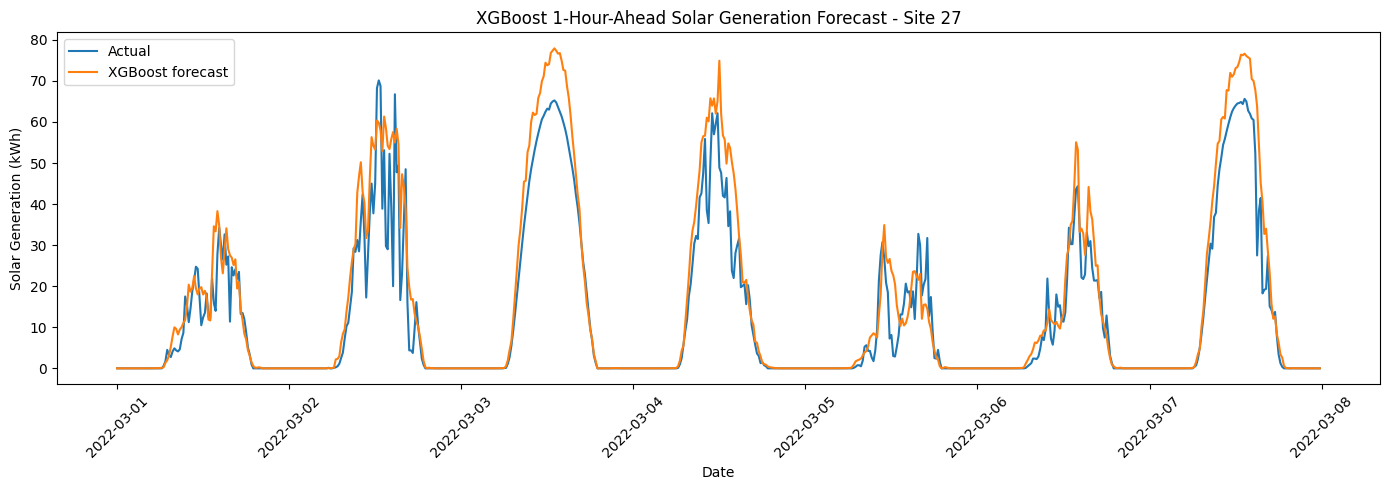

In [ ]:
plot_df = pd.DataFrame({
    'Timestamp': test['Timestamp'].to_numpy(),
    'SiteKey': X_test['SiteKey'].to_numpy(),
    'Actual': y_test.to_numpy(),
    'Prediction': xgb_test_pred,
})

sample = plot_df[
    (plot_df['SiteKey'] == 27) &
    (plot_df['Timestamp'] >= '2022-03-01') &
    (plot_df['Timestamp'] < '2022-03-08')
]

plt.figure(figsize=(14, 5))

plt.plot(
    sample['Timestamp'],
    sample['Actual'],
    label='Actual'
)

plt.plot(
    sample['Timestamp'],
    sample['Prediction'],
    label='XGBoost forecast'
)

plt.xlabel('Date')
plt.ylabel('Solar Generation (kWh)')
plt.title('XGBoost 1-Hour-Ahead Solar Generation Forecast - Site 27')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

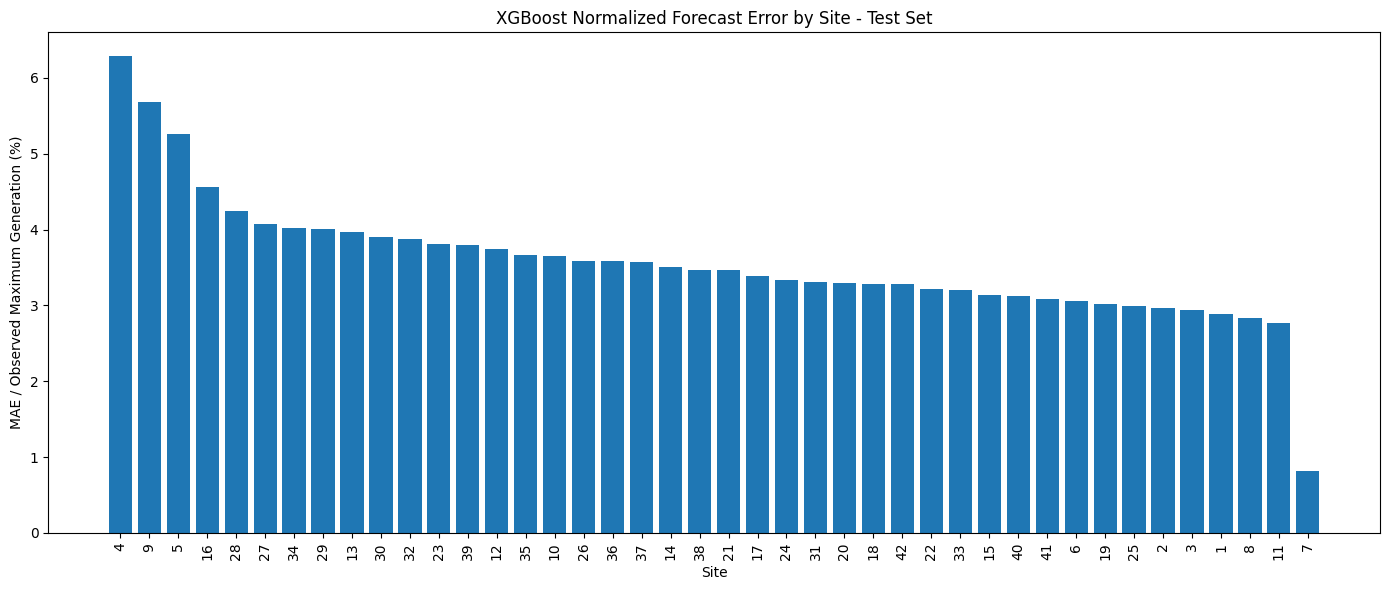

In [ ]:
site_plot = (
    sitewise_xgb
    .sort_values('nMAE_%', ascending=False)
    .reset_index()
)

plt.figure(figsize=(14, 6))

plt.bar(
    site_plot['SiteKey'].astype(str),
    site_plot['nMAE_%']
)

plt.xlabel('Site')
plt.ylabel('MAE / Observed Maximum Generation (%)')
plt.title('XGBoost Normalized Forecast Error by Site - Test Set')

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

## 7. LSTM Forecasting Model

The second machine-learning approach uses a Long Short-Term Memory (LSTM) neural network. Unlike XGBoost, which receives explicit lag features, the LSTM receives a sequence of recent observations and learns temporal relationships directly.

A single global LSTM is trained across all 42 PV sites. Site-specific information is represented through a learned site embedding.


In [ ]:
sequence_features = [
    'SolarGeneration',
    'Ghi',
    'AirTemperature',
    'RelativeHumidity',
    'Hour_sin',
    'Hour_cos',
    'DayOfYear_sin',
    'DayOfYear_cos'
]

In [ ]:
lstm_data = final_df.sort_values(
    ['SiteKey', 'Timestamp']
).reset_index(drop=True).copy()

### 7.1 Sequence Preparation

A three-hour lookback corresponds to 12 observations at the dataset's 15-minute resolution. Sequences are accepted only when the timestamps within the lookback window are continuous. Continuous features and the target are standardized using statistics fitted on the training period only during model selection.


In [ ]:
lookback = 12

lstm_data['SequenceStart'] = (
    lstm_data.groupby('SiteKey')['Timestamp']
    .shift(lookback - 1)
)

In [ ]:
# Fit the feature scaler on the training period only to avoid validation/test leakage during tuning.
feature_scaler = StandardScaler()

feature_scaler.fit(
    lstm_data.loc[
        lstm_data['Timestamp'] < '2021-10-01',
        sequence_features
    ]
)

scaled_features = feature_scaler.transform(
    lstm_data[sequence_features]
).astype('float32')

In [ ]:
# Fit the target scaler using training targets only during model selection.
target_scaler = StandardScaler()

target_scaler.fit(
    lstm_data.loc[
        lstm_data['Timestamp'] < '2021-10-01',
        ['Target_1h']
    ].dropna()
)

scaled_target = np.full(
    len(lstm_data),
    np.nan,
    dtype='float32'
)

valid_target = lstm_data['Target_1h'].notna()

scaled_target[valid_target] = (
    target_scaler.transform(
        lstm_data.loc[
            valid_target,
            ['Target_1h']
        ]
    ).ravel()
)

In [ ]:
# Convert SiteKey values 1-42 to zero-based IDs 0-41 for the embedding layer.
site_keys = (
    lstm_data['SiteKey'].to_numpy()
    .astype('int32') - 1
)

### 7.2 Memory-Efficient Batch Generator

Materializing every LSTM sequence at once would require a very large in-memory array. A custom Keras `Sequence` generator therefore constructs batches dynamically. Each batch contains the historical feature sequence, the corresponding site identifier, and the one-hour-ahead target.


In [ ]:
# Generate sequences batch-by-batch rather than materializing millions of windows in memory.
class PVSequence(tf.keras.utils.Sequence):

    np.random.seed(42)

    def __init__(
        self,
        indices,
        features,
        targets,
        site_keys,
        lookback=12,
        batch_size=512,
        shuffle=False,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.indices = indices.copy()
        self.features = features
        self.targets = targets
        self.site_keys = site_keys
        self.lookback = lookback
        self.batch_size = batch_size
        self.shuffle = shuffle

        self.on_epoch_end()

    def __len__(self):
        return int(
            np.ceil(
                len(self.indices) / self.batch_size
            )
        )

    def __getitem__(self, batch_index):

        batch_indices = self.indices[
            batch_index * self.batch_size:
            (batch_index + 1) * self.batch_size
        ]

        X_sequence = np.stack([
            self.features[
                idx - self.lookback + 1:
                idx + 1
            ]
            for idx in batch_indices
        ])

        X_site = self.site_keys[batch_indices]

        y = self.targets[batch_indices]

        return (
            {
                'sequence_input': X_sequence,
                'site_input': X_site
            },
            y
        )

    def on_epoch_end(self):

        if self.shuffle:
            np.random.shuffle(self.indices)


In [ ]:
# Accept a sequence only when its full lookback window is continuous.
def get_valid_sequence_indices(df, lookback, split):

    sequence_start = (
        df.groupby('SiteKey')['Timestamp']
        .shift(lookback - 1)
    )

    valid_sequence = (
        sequence_start.notna()
        &
        (
            df['Timestamp'] - sequence_start
            ==
            pd.Timedelta(
                minutes=15 * (lookback - 1)
            )
        )
        &
        df['Target_1h'].notna()
    )

    if split == 'train':

        mask = (
            valid_sequence
            &
            (df['Timestamp'] < '2021-10-01')
        )

    elif split == 'val':

        mask = (
            valid_sequence
            &
            (df['Timestamp'] >= '2021-10-01')
            &
            (df['Timestamp'] < '2022-01-01')
        )

    elif split == 'test':

        mask = (
            valid_sequence
            &
            (df['Timestamp'] >= '2022-01-01')
        )

    else:
        raise ValueError(
            'split must be train, val, or test'
        )

    return np.flatnonzero(mask)


### 7.3 LSTM Architecture

The model has two inputs. The historical multivariate sequence is processed by an LSTM layer, while `SiteKey` is transformed into a learned embedding. These representations are concatenated and passed through a dense layer before producing the one-hour-ahead forecast. Mean squared error is used as the training loss.


In [ ]:
def build_lstm_model(
    lookback,
    n_features,
    lstm_units=64,
    dense_units=32,
    dropout=0.0,
    learning_rate=0.001
):

    # Historical sequence input
    sequence_input = layers.Input(
        shape=(lookback, n_features),
        name='sequence_input'
    )

    x = layers.LSTM(
        lstm_units,
        return_sequences=False
    )(sequence_input)

    if dropout > 0:
        x = layers.Dropout(dropout)(x)

    # Site identity input
    site_input = layers.Input(
        shape=(),
        dtype='int32',
        name='site_input'
    )

    site_embedding = layers.Embedding(
        input_dim=42,
        output_dim=8
    )(site_input)

    site_embedding = layers.Flatten()(site_embedding)

    # Combine sequence information with site information
    x = layers.Concatenate()([
        x,
        site_embedding
    ])

    x = layers.Dense(
        dense_units,
        activation='relu'
    )(x)

    output = layers.Dense(1)(x)

    model = Model(
        inputs={
            'sequence_input': sequence_input,
            'site_input': site_input
        },
        outputs=output
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss='mse',
        metrics=['mae']
    )

    return model

### 7.4 Model Training

In [ ]:
train_indices = get_valid_sequence_indices(
    lstm_data,
    lookback,
    'train'
)

val_indices = get_valid_sequence_indices(
    lstm_data,
    lookback,
    'val'
)

# Find valid endpoint sequence
train_gen = PVSequence(
    train_indices,
    scaled_features,
    scaled_target,
    site_keys,
    lookback=lookback,
    batch_size=512,
    shuffle=True
)

val_gen = PVSequence(
    val_indices,
    scaled_features,
    scaled_target,
    site_keys,
    lookback=lookback,
    batch_size=512,
    shuffle=False
)

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

# Build model
model = build_lstm_model(
    lookback=lookback,
    n_features=len(sequence_features),
    lstm_units=64,
    dense_units=32,
    dropout=0.0,
    learning_rate=0.001
)

# Early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Train
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[early_stopping],
    verbose=1
)

# Predict validation data
pred_scaled = model.predict(
    val_gen,
    verbose=1
).ravel()

# Convert predictions back to original units
pred = target_scaler.inverse_transform(
    pred_scaled.reshape(-1, 1)
).ravel()

# Actual values
actual = lstm_data.loc[
    val_indices,
    'Target_1h'
].to_numpy()

# PV generation cannot be negative
pred = np.maximum(pred, 0)

# Metrics
lstm_mae = mean_absolute_error(actual, pred)

lstm_rmse = root_mean_squared_error(actual, pred)

lstm_r2 = r2_score(actual, pred)

print(f'MAE:  {lstm_mae:.4f}')
print(f'RMSE: {lstm_rmse:.4f}')
print(f'R²:   {lstm_r2:.4f}')

Epoch 1/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 153s 45ms/step - loss: 0.0591 - mae: 0.0796 - val_loss: 0.0771 - val_mae: 0.0928
Epoch 2/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 157s 47ms/step - loss: 0.0459 - mae: 0.0676 - val_loss: 0.0754 - val_mae: 0.0929
Epoch 3/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 146s 44ms/step - loss: 0.0445 - mae: 0.0657 - val_loss: 0.0746 - val_mae: 0.0912
Epoch 4/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 146s 44ms/step - loss: 0.0434 - mae: 0.0643 - val_loss: 0.0754 - val_mae: 0.0931
Epoch 5/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 205s 45ms/step - loss: 0.0425 - mae: 0.0633 - val_loss: 0.0751 - val_mae: 0.0933
Epoch 6/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 155s 47ms/step - loss: 0.0419 - mae: 0.0624 - val_loss: 0.0766 - val_mae: 0.0926
638/638 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step
MAE:  0.6908
RMSE: 2.1107
R²:   0.9548


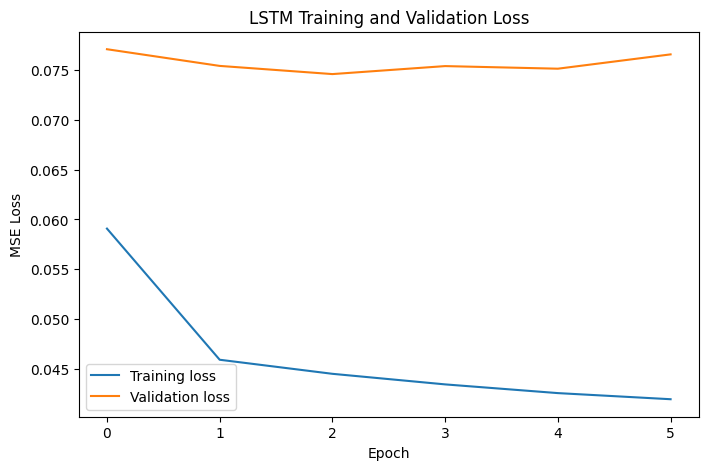

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation loss'
)

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('LSTM Training and Validation Loss')
plt.legend()

plt.show()

### 7.5 LSTM Feature Selection

The initial LSTM model uses a reduced set of input features consisting of solar generation, GHI, selected weather variables, and cyclical time features.

To evaluate the contribution of meteorological information, three feature sets are compared using the validation period:

1. **Irradiance only features:** Solar generation, GHI and cyclical time features.
2. **Reduced weather features:** Solar generation, GHI, Air Temperature, Relative Humidity, and cyclical time features.
3. **Full weather features:** Solar generation, all available weather variables, and cyclical time features.

The same LSTM architecture and training configuration are used for each feature set so that differences in performance can be attributed to the input variables rather than changes in model configuration.

The models are evaluated using MAE, RMSE, and R², with RMSE used as the primary selection metric. A more complex feature set is retained only if the additional variables provide a meaningful improvement in validation performance.

In [ ]:
lstm_fs = pd.DataFrame({
    'Feature Set': ['Full Weather', 'Irradiance Only', 'Reduced Weather'],
    'MAE': [np.nan, np.nan, lstm_mae],
    'RMSE': [np.nan, np.nan, lstm_rmse],
    'R²': [np.nan, np.nan, lstm_r2]
})

lstm_fs.set_index('Feature Set', inplace=True)

lstm_fs

,MAE,RMSE,R²
Feature Set,,,
Full,NaN,NaN,NaN
Irradiance Only,NaN,NaN,NaN
Reduced Weather,0.690776,2.110712,0.954752


#### Irradiance Only Features

In [ ]:
sequence_features_io = [
    'SolarGeneration',
    'Ghi',
    'Hour_sin',
    'Hour_cos',
    'DayOfYear_sin',
    'DayOfYear_cos'
]

In [ ]:
# Feature scaling
feature_scaler_io = StandardScaler()

feature_scaler_io.fit(
    lstm_data.loc[
        lstm_data['Timestamp'] < '2021-10-01',
        sequence_features_io
    ]
)

scaled_features_io = feature_scaler_io.transform(
    lstm_data[sequence_features_io]
).astype('float32')

In [ ]:
# Find valid sequence endpoints
train_indices = get_valid_sequence_indices(
    lstm_data,
    lookback,
    'train'
)

val_indices = get_valid_sequence_indices(
    lstm_data,
    lookback,
    'val'
)

print('Training sequences:', len(train_indices))
print('Validation sequences:', len(val_indices))

# Create generators
train_gen = PVSequence(
    train_indices,
    scaled_features_io,
    scaled_target,
    site_keys,
    lookback=lookback,
    batch_size=512,
    shuffle=True
)

val_gen = PVSequence(
    val_indices,
    scaled_features_io,
    scaled_target,
    site_keys,
    lookback=lookback,
    batch_size=512,
    shuffle=False
)

# Clear previous session
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

# Build model
model = build_lstm_model(
    lookback=lookback,
    n_features=len(sequence_features_io),
    lstm_units=64,
    dense_units=32,
    dropout=0.0,
    learning_rate=0.001
)

# Early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Train
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[early_stopping],
    verbose=1
)

# Predict validation data
pred_scaled = model.predict(
    val_gen,
    verbose=1
).ravel()

# Convert predictions back to original units
pred = target_scaler.inverse_transform(
    pred_scaled.reshape(-1, 1)
).ravel()

# True values
actual = lstm_data.loc[
    val_indices,
    'Target_1h'
].to_numpy()

# PV generation cannot be negative
pred = np.maximum(pred, 0)

# Metrics
lstm_mae_io = mean_absolute_error(actual, pred)

lstm_rmse_io = root_mean_squared_error(actual, pred)

lstm_r2_io = r2_score(actual, pred)

print(f'MAE:  {lstm_mae_io:.4f}')
print(f'RMSE: {lstm_rmse_io:.4f}')
print(f'R²:   {lstm_r2_io:.4f}')

Training sequences: 1692667
Validation sequences: 326350
Epoch 1/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 163s 49ms/step - loss: 0.0595 - mae: 0.0785 - val_loss: 0.0781 - val_mae: 0.0947
Epoch 2/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 156s 47ms/step - loss: 0.0461 - mae: 0.0673 - val_loss: 0.0740 - val_mae: 0.0900
Epoch 3/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 145s 44ms/step - loss: 0.0449 - mae: 0.0655 - val_loss: 0.0747 - val_mae: 0.0914
Epoch 4/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 145s 44ms/step - loss: 0.0440 - mae: 0.0642 - val_loss: 0.0778 - val_mae: 0.0903
Epoch 5/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 142s 43ms/step - loss: 0.0433 - mae: 0.0633 - val_loss: 0.0750 - val_mae: 0.0895
638/638 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step
MAE:  0.6795
RMSE: 2.1023
R²:   0.9551


In [ ]:
lstm_fs.loc['Irradiance Only', 'MAE'] = lstm_mae_io
lstm_fs.loc['Irradiance Only', 'RMSE'] = lstm_rmse_io
lstm_fs.loc['Irradiance Only', 'R²'] = lstm_r2_io

####Full Weather Features

In [ ]:
full_weather_features = [
    'SolarGeneration',
    'Ghi',
    'CloudOpacity',
    'ApparentTemperature',
    'AirTemperature',
    'DewPointTemperature',
    'RelativeHumidity',
    'Hour_sin',
    'Hour_cos',
    'DayOfYear_sin',
    'DayOfYear_cos'
]

In [ ]:
# Feature scaling
feature_scaler_fw = StandardScaler()

feature_scaler_fw.fit(
    lstm_data.loc[
        lstm_data['Timestamp'] < '2021-10-01',
        full_weather_features
    ]
)

scaled_features_fw = feature_scaler_fw.transform(
    lstm_data[full_weather_features]
).astype('float32')

In [ ]:
# Create generators
train_gen = PVSequence(
    train_indices,
    scaled_features_fw,
    scaled_target,
    site_keys,
    lookback=lookback,
    batch_size=512,
    shuffle=True
)

val_gen = PVSequence(
    val_indices,
    scaled_features_fw,
    scaled_target,
    site_keys,
    lookback=lookback,
    batch_size=512,
    shuffle=False
)

# Clear previous session
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

# Build model
model = build_lstm_model(
    lookback=lookback,
    n_features=len(full_weather_features),
    lstm_units=64,
    dense_units=32,
    dropout=0.0,
    learning_rate=0.001
)

# Early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Train
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[early_stopping],
    verbose=1
)

# Predict validation data
pred_scaled = model.predict(
    val_gen,
    verbose=1
).ravel()

# Convert predictions back to original units
pred = target_scaler.inverse_transform(
    pred_scaled.reshape(-1, 1)
).ravel()

# True values
actual = lstm_data.loc[
    val_indices,
    'Target_1h'
].to_numpy()

# PV generation cannot be negative
pred = np.maximum(pred, 0)

# Metrics
lstm_mae_fw = mean_absolute_error(actual, pred)

lstm_rmse_fw = root_mean_squared_error(actual, pred)

lstm_r2_fw = r2_score(actual, pred)

print(f'MAE:  {lstm_mae_fw:.4f}')
print(f'RMSE: {lstm_rmse_fw:.4f}')
print(f'R²:   {lstm_r2_fw:.4f}')

Epoch 1/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 152s 45ms/step - loss: 0.0572 - mae: 0.0802 - val_loss: 0.0775 - val_mae: 0.1014
Epoch 2/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 150s 45ms/step - loss: 0.0452 - mae: 0.0685 - val_loss: 0.0798 - val_mae: 0.0942
Epoch 3/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 159s 48ms/step - loss: 0.0439 - mae: 0.0661 - val_loss: 0.0796 - val_mae: 0.0943
Epoch 4/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 153s 46ms/step - loss: 0.0431 - mae: 0.0643 - val_loss: 0.0757 - val_mae: 0.0928
Epoch 5/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 151s 46ms/step - loss: 0.0422 - mae: 0.0628 - val_loss: 0.0741 - val_mae: 0.0892
Epoch 6/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 150s 45ms/step - loss: 0.0414 - mae: 0.0621 - val_loss: 0.0766 - val_mae: 0.0893
Epoch 7/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 149s 45ms/step - loss: 0.0408 - mae: 0.0616 - val_loss: 0.0763 - val_mae: 0.0893
Epoch 8/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 157s 48ms/step - loss: 0.0399 - mae: 0.0608 - val_loss: 0.0807 - val_mae: 0.0911
638/638 ━━━━━━━━

In [ ]:
lstm_fs.loc['Full Weather', 'MAE'] = lstm_mae_fw
lstm_fs.loc['Full Weather', 'RMSE'] = lstm_rmse_fw
lstm_fs.loc['Full Weather', 'R²'] = lstm_r2_fw

#### Feature Selection Result

In [ ]:
lstm_fs.sort_values('RMSE')

,MAE,RMSE,R²
Feature Set,,,
Irradiance Only,0.679463,2.102263,0.955114
Full Weather,0.675802,2.102907,0.955086
Reduced Weather,0.690776,2.110712,0.954752
Full,NaN,NaN,NaN


 The Full Weather model achieved the lowest MAE, while the Irradiance Only model achieved the lowest RMSE and highest R². The differences between the Irradiance Only and Full Weather models were very small, indicating that the additional meteorological variables provided little improvement in forecasting performance.

Since RMSE was used as the primary model-selection metric, and the simpler model achieved the lowest RMSE while using fewer input variables, the **Irradiance Only feature set was selected** for subsequent LSTM hyperparameter tuning.

### 7.6 LSTM Hyperparameter Selection

Validation experiments compare lookback length, number of LSTM units, dropout, and learning rate. Early stopping is used during tuning so training stops when validation loss no longer improves.


#### Lookback Length


In [ ]:
lookbacks = {
    '1 hour': 4,
    '3 hours': 12,
    '6 hours': 24
}

lookback_results = []
lookback_models = {}


for name, lookback in lookbacks.items():

    print('\n' + '=' * 50)
    print(f'Training lookback: {name}')
    print('=' * 50)


    # Clear previous TensorFlow model
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(42)

    # Find valid sequence endpoints
    train_indices_lb = get_valid_sequence_indices(
        lstm_data,
        lookback,
        'train'
    )

    val_indices_lb = get_valid_sequence_indices(
        lstm_data,
        lookback,
        'val'
    )

    print('Training sequences:', len(train_indices_lb))
    print('Validation sequences:', len(val_indices_lb))

    # Create generators
    train_gen_lb = PVSequence(
        train_indices_lb,
        scaled_features_io,
        scaled_target,
        site_keys,
        lookback=lookback,
        batch_size=512,
        shuffle=True
    )

    val_gen_lb = PVSequence(
        val_indices_lb,
        scaled_features_io,
        scaled_target,
        site_keys,
        lookback=lookback,
        batch_size=512,
        shuffle=False
    )



    # Build model
    model = build_lstm_model(
        lookback=lookback,
        n_features=len(sequence_features_io),
        lstm_units=64,
        dense_units=32,
        dropout=0.0,
        learning_rate=0.001
    )

    # Early stopping
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

    # Train
    history = model.fit(
        train_gen_lb,
        validation_data=val_gen_lb,
        epochs=20,
        callbacks=[early_stopping],
        verbose=1
    )

    # Predict validation data
    pred_scaled = model.predict(
        val_gen_lb,
        verbose=1
    ).ravel()

    # Convert predictions back to original units
    pred = target_scaler.inverse_transform(
        pred_scaled.reshape(-1, 1)
    ).ravel()

    # True values
    actual = lstm_data.loc[
        val_indices_lb,
        'Target_1h'
    ].to_numpy()

    # PV generation cannot be negative
    pred = np.maximum(pred, 0)

    # Metrics
    mae = mean_absolute_error(actual, pred)

    rmse = root_mean_squared_error(actual, pred)

    r2 = r2_score(actual, pred)

    print(f'\n{name}')
    print(f'MAE:  {mae:.4f}')
    print(f'RMSE: {rmse:.4f}')
    print(f'R²:   {r2:.4f}')

    lookback_results.append({
        'Lookback': name,
        'Timesteps': lookback,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'Best_epoch':
            np.argmin(history.history['val_loss']) + 1
    })

    lookback_models[name] = model


Training lookback: 1 hour
Training sequences: 1735672
Validation sequences: 337802
Epoch 1/20
3390/3390 ━━━━━━━━━━━━━━━━━━━━ 70s 20ms/step - loss: 0.0614 - mae: 0.0812 - val_loss: 0.0855 - val_mae: 0.0962
Epoch 2/20
3390/3390 ━━━━━━━━━━━━━━━━━━━━ 67s 20ms/step - loss: 0.0477 - mae: 0.0692 - val_loss: 0.0778 - val_mae: 0.0929
Epoch 3/20
3390/3390 ━━━━━━━━━━━━━━━━━━━━ 67s 20ms/step - loss: 0.0465 - mae: 0.0676 - val_loss: 0.0777 - val_mae: 0.0935
Epoch 4/20
3390/3390 ━━━━━━━━━━━━━━━━━━━━ 65s 19ms/step - loss: 0.0456 - mae: 0.0665 - val_loss: 0.0789 - val_mae: 0.0918
Epoch 5/20
3390/3390 ━━━━━━━━━━━━━━━━━━━━ 66s 19ms/step - loss: 0.0451 - mae: 0.0657 - val_loss: 0.0761 - val_mae: 0.0923
Epoch 6/20
3390/3390 ━━━━━━━━━━━━━━━━━━━━ 66s 20ms/step - loss: 0.0447 - mae: 0.0650 - val_loss: 0.0780 - val_mae: 0.0907
Epoch 7/20
3390/3390 ━━━━━━━━━━━━━━━━━━━━ 69s 20ms/step - loss: 0.0443 - mae: 0.0645 - val_loss: 0.0761 - val_mae: 0.0933
Epoch 8/20
3390/3390 ━━━━━━━━━━━━━━━━━━━━ 65s 19ms/step - loss

In [ ]:
lookback_results = pd.DataFrame(
    lookback_results
)

lookback_results.sort_values('RMSE')

,Lookback,Timesteps,MAE,RMSE,R²,Best_epoch
1,3 hours,12,0.683019,2.108501,0.954847,4
0,1 hour,4,0.693839,2.131132,0.954672,5
2,6 hours,24,0.691258,2.161103,0.954036,2


Three historical sequence lengths were evaluated: 1 hour, 3 hours, and 6 hours. The **3-hour lookback produced the lowest MAE and RMSE**, while the difference in R² between the 1-hour and 3-hour models was negligible.

A **3-hour lookback, corresponding to 12 observations at 15-minute intervals, was therefore selected**. This provides the LSTM with sufficient recent history without unnecessarily increasing sequence length and computational cost

In [ ]:
lookback = 12

train_indices_3h = get_valid_sequence_indices(
    lstm_data,
    lookback,
    'train'
)

val_indices_3h = get_valid_sequence_indices(
    lstm_data,
    lookback,
    'val'
)

print('Training sequences:', len(train_indices_3h))
print('Validation sequences:', len(val_indices_3h))

Training sequences: 1692667
Validation sequences: 326350


#### Number of LSTM Units


In [ ]:
unit_options = [32, 64, 128]

unit_results = []
unit_models = {}

for units in unit_options:

    print('\n' + '=' * 50)
    print(f'Training LSTM with {units} units')
    print('=' * 50)

    # Clear previous TensorFlow model
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(42)

    # Fresh generators
    train_gen_units = PVSequence(
        train_indices_3h,
        scaled_features_io,
        scaled_target,
        site_keys,
        lookback=lookback,
        batch_size=512,
        shuffle=True
    )

    val_gen_units = PVSequence(
        val_indices_3h,
        scaled_features_io,
        scaled_target,
        site_keys,
        lookback=lookback,
        batch_size=512,
        shuffle=False
    )

    # Build model
    model = build_lstm_model(
        lookback=lookback,
        n_features=len(sequence_features_io),
        lstm_units=units,
        dense_units=32,
        dropout=0.0,
        learning_rate=0.001
    )

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

    # Train
    history = model.fit(
        train_gen_units,
        validation_data=val_gen_units,
        epochs=20,
        callbacks=[early_stopping],
        verbose=1
    )

    # Validation predictions
    pred_scaled = model.predict(
        val_gen_units,
        verbose=1
    ).ravel()

    pred = target_scaler.inverse_transform(
        pred_scaled.reshape(-1, 1)
    ).ravel()

    pred = np.maximum(pred, 0)

    actual = lstm_data.loc[
        val_indices_3h,
        'Target_1h'
    ].to_numpy()

    # Metrics
    mae = mean_absolute_error(actual, pred)

    rmse = root_mean_squared_error(actual, pred)

    r2 = r2_score(actual, pred)

    best_epoch = (
        np.argmin(history.history['val_loss']) + 1
    )

    print(f'\n{units} LSTM units')
    print(f'MAE:  {mae:.4f}')
    print(f'RMSE: {rmse:.4f}')
    print(f'R²:   {r2:.4f}')
    print(f'Best epoch: {best_epoch}')

    unit_results.append({
        'LSTM_units': units,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'Best_epoch': best_epoch
    })

    unit_models[units] = model


Training LSTM with 32 units
Epoch 1/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 105s 30ms/step - loss: 0.0650 - mae: 0.0830 - val_loss: 0.0780 - val_mae: 0.0984
Epoch 2/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 86s 26ms/step - loss: 0.0461 - mae: 0.0687 - val_loss: 0.0760 - val_mae: 0.0944
Epoch 3/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 87s 26ms/step - loss: 0.0448 - mae: 0.0672 - val_loss: 0.0784 - val_mae: 0.0916
Epoch 4/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 84s 25ms/step - loss: 0.0439 - mae: 0.0658 - val_loss: 0.0754 - val_mae: 0.0917
Epoch 5/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 84s 25ms/step - loss: 0.0434 - mae: 0.0648 - val_loss: 0.0735 - val_mae: 0.0913
Epoch 6/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 84s 25ms/step - loss: 0.0430 - mae: 0.0641 - val_loss: 0.0745 - val_mae: 0.0899
Epoch 7/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 84s 25ms/step - loss: 0.0426 - mae: 0.0634 - val_loss: 0.0761 - val_mae: 0.0903
Epoch 8/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 88s 27ms/step - loss: 0.0424 - mae: 0.0631 - val_loss: 0.0743 - val_mae: 0

In [ ]:
unit_results = pd.DataFrame(unit_results)

unit_results.sort_values('RMSE')

,LSTM_units,MAE,RMSE,R²,Best_epoch
0,32,0.693320,2.094354,0.955451,5
1,64,0.683019,2.108501,0.954847,4
2,128,0.681670,2.109287,0.954813,4


The three configurations produced similar validation performance. The 128-unit model achieved the lowest MAE, while the 32-unit model achieved the lowest RMSE and highest R².

Since RMSE was used as the primary metric for model selection, **32 LSTM units were selected**. The 32-unit configuration also has lower model complexity than the larger alternatives while providing comparable or better overall validation performance.

#### Dropout


In [ ]:
dropout_options = [0.0, 0.1, 0.2]

dropout_results = []
dropout_models = {}

for dropout in dropout_options:

    print('\n' + '=' * 50)
    print(f'Training LSTM with dropout = {dropout}')
    print('=' * 50)

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(42)

    train_gen_dropout = PVSequence(
        train_indices_3h,
        scaled_features_io,
        scaled_target,
        site_keys,
        lookback=lookback,
        batch_size=512,
        shuffle=True
    )

    val_gen_dropout = PVSequence(
        val_indices_3h,
        scaled_features_io,
        scaled_target,
        site_keys,
        lookback=lookback,
        batch_size=512,
        shuffle=False
    )

    model = build_lstm_model(
        lookback=lookback,
        n_features=len(sequence_features_io),
        lstm_units=32,
        dense_units=32,
        dropout=dropout,
        learning_rate=0.001
    )

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

    history = model.fit(
        train_gen_dropout,
        validation_data=val_gen_dropout,
        epochs=20,
        callbacks=[early_stopping],
        verbose=1
    )

    pred_scaled = model.predict(
        val_gen_dropout,
        verbose=1
    ).ravel()

    pred = target_scaler.inverse_transform(
        pred_scaled.reshape(-1, 1)
    ).ravel()

    pred = np.maximum(pred, 0)

    actual = lstm_data.loc[
        val_indices_3h,
        'Target_1h'
    ].to_numpy()

    mae = mean_absolute_error(actual, pred)

    rmse = root_mean_squared_error(actual, pred)

    r2 = r2_score(actual, pred)

    best_epoch = (
        np.argmin(history.history['val_loss']) + 1
    )

    print(f'\nDropout = {dropout}')
    print(f'MAE:  {mae:.4f}')
    print(f'RMSE: {rmse:.4f}')
    print(f'R²:   {r2:.4f}')
    print(f'Best epoch: {best_epoch}')

    dropout_results.append({
        'Dropout': dropout,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'Best_epoch': best_epoch
    })

    dropout_models[dropout] = model


Training LSTM with dropout = 0.0
Epoch 1/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 91s 27ms/step - loss: 0.0650 - mae: 0.0830 - val_loss: 0.0780 - val_mae: 0.0984
Epoch 2/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 89s 27ms/step - loss: 0.0461 - mae: 0.0687 - val_loss: 0.0760 - val_mae: 0.0944
Epoch 3/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 142s 27ms/step - loss: 0.0448 - mae: 0.0672 - val_loss: 0.0784 - val_mae: 0.0916
Epoch 4/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 87s 26ms/step - loss: 0.0439 - mae: 0.0658 - val_loss: 0.0754 - val_mae: 0.0917
Epoch 5/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 88s 27ms/step - loss: 0.0434 - mae: 0.0648 - val_loss: 0.0735 - val_mae: 0.0913
Epoch 6/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 87s 26ms/step - loss: 0.0430 - mae: 0.0641 - val_loss: 0.0745 - val_mae: 0.0899
Epoch 7/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 88s 27ms/step - loss: 0.0426 - mae: 0.0634 - val_loss: 0.0761 - val_mae: 0.0903
Epoch 8/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 88s 27ms/step - loss: 0.0424 - mae: 0.0631 - val_loss: 0.0743 - val_m

In [ ]:
dropout_results = pd.DataFrame(
    dropout_results
)

dropout_results.sort_values('RMSE')

,Dropout,MAE,RMSE,R²,Best_epoch
0,0.0,0.693320,2.094354,0.955451,5
1,0.1,0.719498,2.105356,0.954981,4
2,0.2,0.828848,2.139642,0.953503,4


The model without dropout achieved the best validation performance across all three evaluation metrics, with the lowest MAE and RMSE and the highest R². Increasing the dropout rate to 0.1 and 0.2 resulted in progressively poorer performance.

Therefore, **no dropout (`dropout = 0.0`) was selected** for the final LSTM model.

#### Learning Rate



In [ ]:
learning_rates = [0.001, 0.0005]

lr_results_lstm = []
lr_models = {}

for lr in learning_rates:

    print('\n' + '=' * 50)
    print(f'Training LSTM with learning rate = {lr}')
    print('=' * 50)

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(42)

    train_gen_lr = PVSequence(
        train_indices_3h,
        scaled_features_io,
        scaled_target,
        site_keys,
        lookback=lookback,
        batch_size=512,
        shuffle=True
    )

    val_gen_lr = PVSequence(
        val_indices_3h,
        scaled_features_io,
        scaled_target,
        site_keys,
        lookback=lookback,
        batch_size=512,
        shuffle=False
    )

    model = build_lstm_model(
        lookback=lookback,
        n_features=len(sequence_features_io),
        lstm_units=32,
        dense_units=32,
        dropout=0.0,
        learning_rate=lr
    )

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

    history = model.fit(
        train_gen_lr,
        validation_data=val_gen_lr,
        epochs=20,
        callbacks=[early_stopping],
        verbose=1
    )

    pred_scaled = model.predict(
        val_gen_lr,
        verbose=1
    ).ravel()

    pred = target_scaler.inverse_transform(
        pred_scaled.reshape(-1, 1)
    ).ravel()

    pred = np.maximum(pred, 0)

    actual = lstm_data.loc[
        val_indices_3h,
        'Target_1h'
    ].to_numpy()

    mae = mean_absolute_error(actual, pred)

    rmse = root_mean_squared_error(actual, pred)

    r2 = r2_score(actual, pred)

    best_epoch = (
        np.argmin(history.history['val_loss']) + 1
    )

    print(f'\nLearning rate = {lr}')
    print(f'MAE:  {mae:.4f}')
    print(f'RMSE: {rmse:.4f}')
    print(f'R²:   {r2:.4f}')
    print(f'Best epoch: {best_epoch}')

    lr_results_lstm.append({
        'Learning_rate': lr,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'Best_epoch': best_epoch
    })

    lr_models[lr] = model


Training LSTM with learning rate = 0.001
Epoch 1/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 101s 28ms/step - loss: 0.0650 - mae: 0.0830 - val_loss: 0.0780 - val_mae: 0.0984
Epoch 2/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 90s 27ms/step - loss: 0.0461 - mae: 0.0687 - val_loss: 0.0760 - val_mae: 0.0944
Epoch 3/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 87s 26ms/step - loss: 0.0448 - mae: 0.0672 - val_loss: 0.0784 - val_mae: 0.0916
Epoch 4/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 87s 26ms/step - loss: 0.0439 - mae: 0.0658 - val_loss: 0.0754 - val_mae: 0.0917
Epoch 5/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 86s 26ms/step - loss: 0.0434 - mae: 0.0648 - val_loss: 0.0735 - val_mae: 0.0913
Epoch 6/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 85s 26ms/step - loss: 0.0430 - mae: 0.0641 - val_loss: 0.0745 - val_mae: 0.0899
Epoch 7/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 85s 26ms/step - loss: 0.0426 - mae: 0.0634 - val_loss: 0.0761 - val_mae: 0.0903
Epoch 8/20
3306/3306 ━━━━━━━━━━━━━━━━━━━━ 86s 26ms/step - loss: 0.0424 - mae: 0.0631 - val_loss: 0.0743

In [ ]:
lr_results_lstm = pd.DataFrame(lr_results_lstm)
lr_results_lstm.sort_values('RMSE')

,Learning_rate,MAE,RMSE,R²,Best_epoch
0,0.0010,0.693320,2.094354,0.955451,5
1,0.0005,0.685969,2.116615,0.954499,4


The learning rate of 0.001 achieved better validation performance than 0.0005, producing the lowest MAE and RMSE and the highest R².

Therefore, **`learning_rate = 0.001` was selected** for the final LSTM model.

### Final LSTM Configuration

Based on the validation experiments, the final LSTM model uses:

- **Lookback:** 3 hours (12 × 15-minute observations)
- **LSTM units:** 32
- **Dense units:** 32
- **Dropout:** 0.0
- **Learning rate:** 0.001
- **Batch size:** 512
- **Site embedding dimension:** 8
- **Training epochs:** 5

The sequence features are:

- Solar Generation
- GHI
- Hour of day (sine and cosine)
- Day of year (sine and cosine)

After model selection, the training and validation periods were combined to provide the final model with all available pre-test data. The final model was trained for four epochs and evaluated on the held-out test period.

### 7.6 Final LSTM Model

The selected LSTM configuration is retrained using the combined pre-test data and then evaluated on the held-out 2022 test period. The final sequence uses PV generation, GHI, and cyclical time features. Negative predictions are clipped to zero for physical consistency.


In [ ]:
sequence_features_io = [
    'SolarGeneration',
    'Ghi',
    'Hour_sin',
    'Hour_cos',
    'DayOfYear_sin',
    'DayOfYear_cos'
]

# Final LSTM configuration selected from the validation experiments above.
lookback = 12
learning_rate = 0.001
lstm_units = 32
dropout = 0.0
batch_size = 512
dense_units = 32
final_epochs = 5


In [ ]:
# Refit feature scaling using the combined pre-test period for final LSTM training.
feature_scaler_final = StandardScaler()

feature_scaler_final.fit(
    lstm_data.loc[
        lstm_data['Timestamp'] < '2022-01-01',
        sequence_features_io
    ]
)

scaled_features_final = feature_scaler_final.transform(
    lstm_data[sequence_features_io]
).astype('float32')


In [ ]:
# Refit the target scaler on the combined pre-test period used for final training.
target_scaler_final = StandardScaler()

target_scaler_final.fit(
    lstm_data.loc[
        lstm_data['Timestamp'] < '2022-01-01',
        ['Target_1h']
    ].dropna()
)


scaled_target_final = np.full(
    len(lstm_data),
    np.nan,
    dtype='float32'
)

valid_target = lstm_data['Target_1h'].notna()

scaled_target_final[valid_target] = (
    target_scaler_final.transform(
        lstm_data.loc[
            valid_target,
            ['Target_1h']
        ]
    ).ravel()
)


In [ ]:
# Obtain valid sequence endpoints for the original training and validation periods.
train_indices = get_valid_sequence_indices(
    lstm_data,
    lookback,
    'train'
)

val_indices = get_valid_sequence_indices(
    lstm_data,
    lookback,
    'val'
)

# Combine training and validation sequences for final pre-test training.
train_indices_final = np.concatenate([
    train_indices,
    val_indices,
])

test_indices = get_valid_sequence_indices(
    lstm_data,
    lookback,
    'test'
)

train_gen_final = PVSequence(
    train_indices_final,
    scaled_features_final,
    scaled_target_final,
    site_keys,
    lookback=lookback,
    batch_size=batch_size,
    shuffle=True
)

test_gen = PVSequence(
    test_indices,
    scaled_features_final,
    scaled_target_final,
    site_keys,
    lookback=lookback,
    batch_size=batch_size,
    shuffle=False
)

# Set reproducibility controls before model weights are initialized.
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

model = build_lstm_model(
    lookback=lookback,
    n_features=len(sequence_features_io),
    lstm_units=lstm_units,
    dense_units=dense_units,
    dropout=dropout,
    learning_rate=learning_rate
)

# Train for the selected number of epochs on all pre-test data.
history = model.fit(
    train_gen_final,
    epochs=final_epochs,
    verbose=1
)

# Generate forecasts for the held-out test sequences.
pred_scaled = model.predict(
    test_gen,
    verbose=1
).ravel()

# Convert forecasts back to the original generation scale.
lstm_test_pred = target_scaler_final.inverse_transform(
    pred_scaled.reshape(-1, 1)
).ravel()

lstm_test_actual = lstm_data.loc[
    test_indices,
    'Target_1h'
].to_numpy()

# PV generation cannot be negative.
lstm_test_pred = np.maximum(lstm_test_pred, 0)

lstm_test_mae = mean_absolute_error(lstm_test_actual, lstm_test_pred)
lstm_test_rmse = root_mean_squared_error(lstm_test_actual, lstm_test_pred)
lstm_test_r2 = r2_score(lstm_test_actual, lstm_test_pred)

print('Final LSTM Test Results')
print('-----------------------')
print(f'LSTM test MAE:  {lstm_test_mae:.4f}')
print(f'LSTM test RMSE: {lstm_test_rmse:.4f}')
print(f'LSTM test R²:   {lstm_test_r2:.4f}')


Epoch 1/5
3944/3944 ━━━━━━━━━━━━━━━━━━━━ 97s 24ms/step - loss: 0.0609 - mae: 0.0809
Epoch 2/5
3944/3944 ━━━━━━━━━━━━━━━━━━━━ 97s 25ms/step - loss: 0.0452 - mae: 0.0686
Epoch 3/5
3944/3944 ━━━━━━━━━━━━━━━━━━━━ 97s 25ms/step - loss: 0.0439 - mae: 0.0666
Epoch 4/5
3944/3944 ━━━━━━━━━━━━━━━━━━━━ 96s 24ms/step - loss: 0.0432 - mae: 0.0654
Epoch 5/5
3944/3944 ━━━━━━━━━━━━━━━━━━━━ 97s 24ms/step - loss: 0.0427 - mae: 0.0645
828/828 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step
Final LSTM Test Results
-----------------------
LSTM test MAE:  0.6197
LSTM test RMSE: 1.8425
LSTM test R²:   0.9598


In [ ]:
test_results.loc['LSTM', 'MAE (Overall)'] = lstm_test_mae
test_results.loc['LSTM', 'RMSE (Overall)'] = lstm_test_rmse
test_results.loc['LSTM', 'R² (Overall)'] = lstm_test_r2

### 7.7 Active-Generation Evaluation

Overall metrics include nighttime periods when generation is frequently zero. To provide a more demanding assessment, the LSTM is also evaluated only where the one-hour-ahead target is greater than zero.


In [ ]:
active_mask = lstm_test_actual > 0

active_actual = lstm_test_actual[active_mask]
active_pred = lstm_test_pred[active_mask]

lstm_active_mae = mean_absolute_error(active_actual, active_pred)
lstm_active_rmse = root_mean_squared_error(active_actual, active_pred)
lstm_active_r2 = r2_score(active_actual, active_pred)

print('Active-generation observations:', len(active_actual))
print('LSTM Active-generation Test Results')
print('-----------------------------------')
print(f'MAE:  {lstm_active_mae:.4f}')
print(f'RMSE: {lstm_active_rmse:.4f}')
print(f'R²:   {lstm_active_r2:.4f}')


Active-generation observations: 205363
LSTM Active-generation Test Results
-----------------------------------
MAE:  1.2009
RMSE: 2.6427
R²:   0.9515


In [ ]:
test_results.loc['LSTM', 'MAE (Active Generation)'] = lstm_active_mae
test_results.loc['LSTM', 'RMSE (Active Generation)'] = lstm_active_rmse
test_results.loc['LSTM', 'R² (Active Generation)'] = lstm_active_r2

### 7.8 LSTM Site-Level Performance

Because the installations differ substantially in generation scale, site-level MAE is normalized by the maximum observed target generation for each site:

$$nMAE=\frac{MAE}{P_{max}}\times100$$

This uses the observed test maximum rather than rated capacity because rated PV capacities are not used in the modelling dataset.


In [ ]:
# Store final LSTM predictions with their site and forecast-origin timestamps.
lstm_site_results = lstm_data.loc[
    test_indices,
    ['SiteKey', 'Timestamp']
].copy()

lstm_site_results['Actual'] = lstm_test_actual
lstm_site_results['Predicted'] = lstm_test_pred

lstm_site_results.head()


,SiteKey,Timestamp,Actual,Predicted
66734,1,2022-01-01 00:00:00,0.0,0.115846
66735,1,2022-01-01 00:15:00,0.0,0.111994
66736,1,2022-01-01 00:30:00,0.0,0.109207
66737,1,2022-01-01 00:45:00,0.0,0.105184
66738,1,2022-01-01 01:00:00,0.0,0.100067


In [ ]:
# Normalize site MAE by the maximum observed target generation for consistency with XGBoost.
sitewise_lstm = []

for site, group in lstm_site_results.groupby('SiteKey'):

    actual = group['Actual']
    predicted = group['Predicted']

    mae = mean_absolute_error(actual, predicted)

    rmse = root_mean_squared_error(actual, predicted)

    r2 = r2_score(actual, predicted)

    max_generation = actual.max()

    # Same normalization used for XGBoost
    nmae = (mae / max_generation) * 100

    sitewise_lstm.append({
        'SiteKey': site,
        'Count': len(group),
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'MaxGeneration': max_generation,
        'nMAE (%)': nmae
    })


In [ ]:
sitewise_lstm = pd.DataFrame(sitewise_lstm)

sitewise_lstm.sort_values(
    'nMAE (%)',
    ascending=False
).round(3)

,SiteKey,Count,MAE,RMSE,R²,MaxGeneration,nMAE (%)
3,4,9849,0.187,0.225,0.859,1.992,9.385
8,9,8533,0.189,0.223,0.888,2.012,9.370
4,5,8395,0.186,0.226,0.837,2.000,9.286
27,28,9589,0.225,0.299,0.889,3.465,6.501
15,16,9631,0.209,0.301,0.902,3.309,6.324
28,29,10250,0.194,0.262,0.905,3.305,5.872
33,34,10134,0.219,0.327,0.927,3.992,5.482
31,32,10327,0.333,0.543,0.921,7.359,4.531
12,13,10086,0.575,1.198,0.836,12.969,4.437
40,41,9960,0.960,1.676,0.940,21.938,4.378


### 7.9 LSTM Forecast and Normalized Error Plots

The same Site 27 week and the same normalized-error ordering used for XGBoost are used here so that the visualizations are directly comparable.


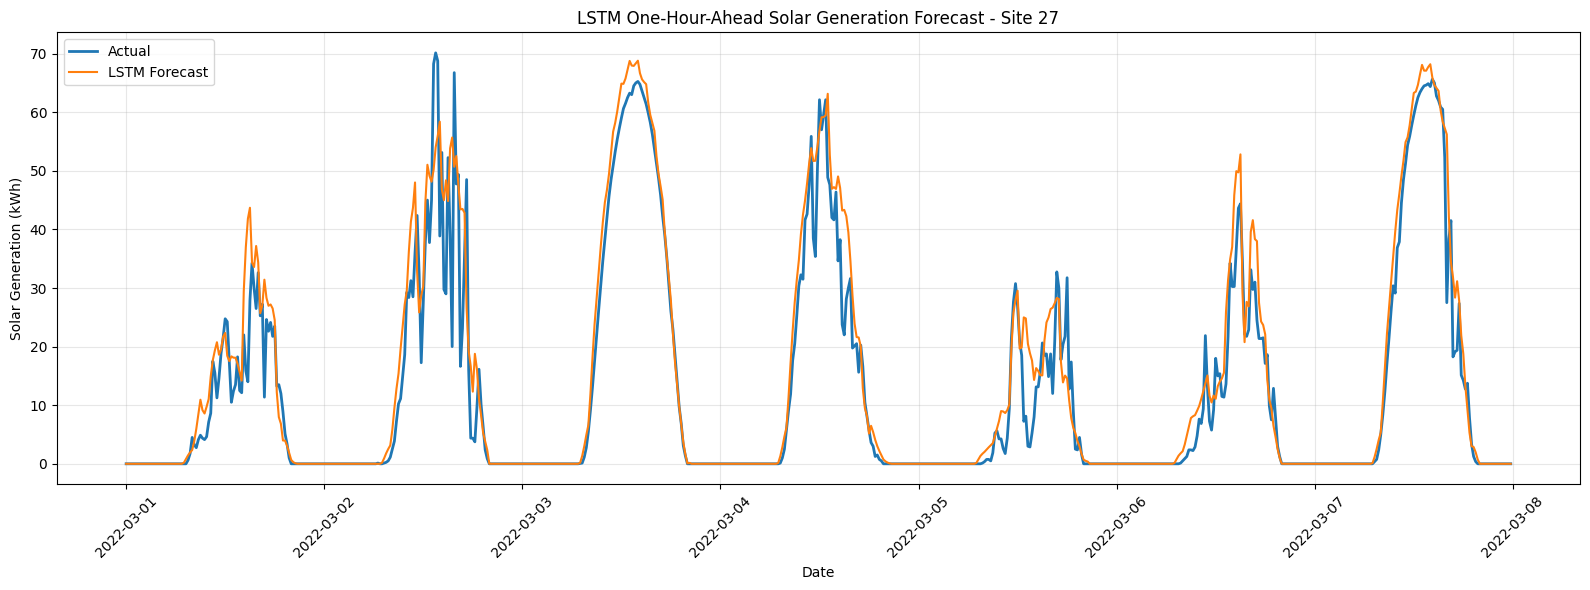

In [ ]:
# Plot predictions at their target time (one hour after the forecast origin).
plot_data = lstm_site_results[
    lstm_site_results['SiteKey'] == 27
].copy()

plot_data['ForecastTime'] = (
    plot_data['Timestamp'] + pd.Timedelta(hours=1)
)

plot_data = plot_data[
    (plot_data['ForecastTime'] >= '2022-03-01') &
    (plot_data['ForecastTime'] < '2022-03-08')
]

plt.figure(figsize=(16, 6))
plt.plot(
    plot_data['ForecastTime'],
    plot_data['Actual'],
    label='Actual',
    linewidth=2
)
plt.plot(
    plot_data['ForecastTime'],
    plot_data['Predicted'],
    label='LSTM Forecast',
    linewidth=1.5
)

plt.xlabel('Date')
plt.ylabel('Solar Generation (kWh)')
plt.title('LSTM One-Hour-Ahead Solar Generation Forecast - Site 27')
plt.legend()
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


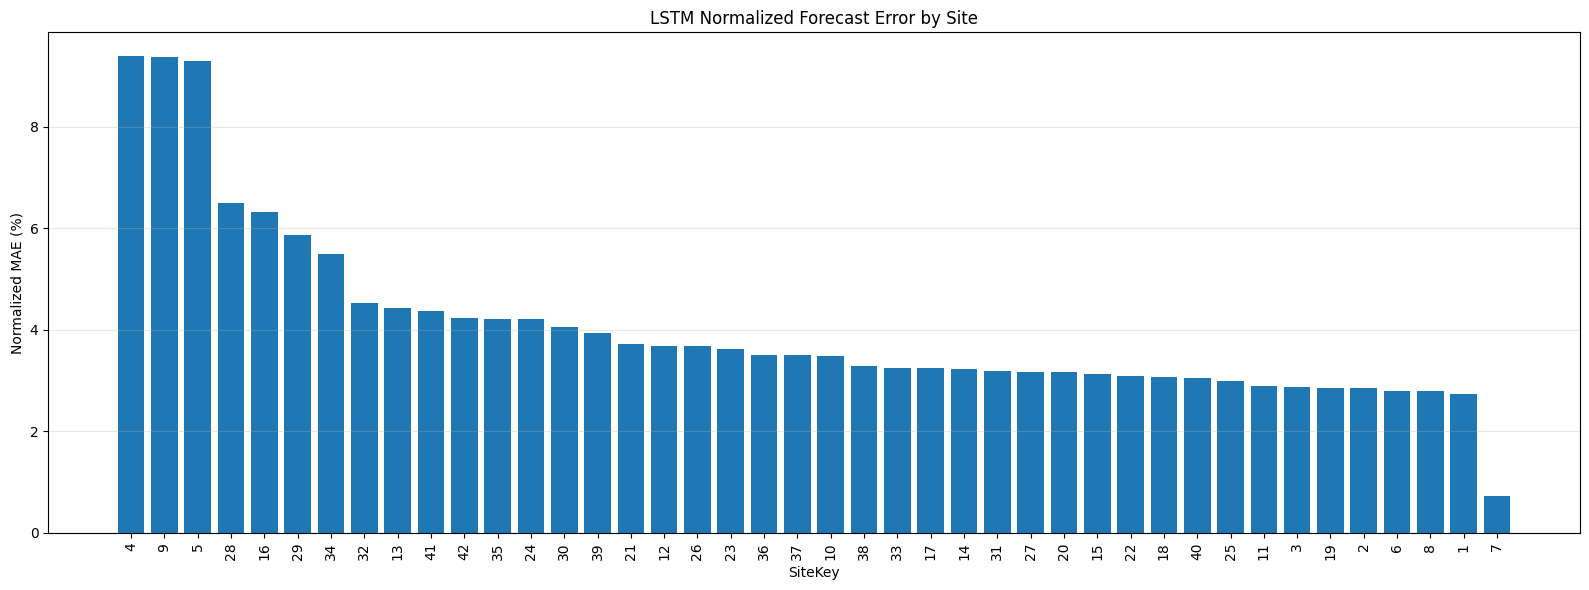

In [ ]:
# Order sites from highest to lowest normalized error, matching the XGBoost visualization.
# Sort sites from highest to lowest normalized MAE
plot_sitewise = (
    sitewise_lstm
    .sort_values('nMAE (%)', ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(16, 6))

plt.bar(
    plot_sitewise['SiteKey'].astype(str),
    plot_sitewise['nMAE (%)']
)

plt.xlabel('SiteKey')
plt.ylabel('Normalized MAE (%)')
plt.title('LSTM Normalized Forecast Error by Site')

plt.xticks(rotation=90)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Final Model Comparison

The persistence baseline, XGBoost, and LSTM are compared on the held-out test period. MAE measures typical absolute forecast error, RMSE places greater weight on larger errors, and R² summarizes the proportion of variation explained by each model.

A combined one-week Site 27 plot provides a direct visual comparison between the XGBoost and LSTM forecasts.


In [ ]:
xgb_compare = xgb_site_results[
    ['SiteKey', 'Timestamp', 'Actual', 'Predicted']
].copy()

xgb_compare = xgb_compare.rename(
    columns={
        'Predicted': 'XGBoost'
    }
)

lstm_compare = lstm_site_results[
    ['SiteKey', 'Timestamp', 'Actual', 'Predicted']
].copy()

lstm_compare = lstm_compare.rename(
    columns={
        'Predicted': 'LSTM'
    }
)

In [ ]:
# Keep only timestamps for which both models have a prediction, enabling a fair visual comparison.
forecast_compare = pd.merge(
    xgb_compare,
    lstm_compare[
        ['SiteKey', 'Timestamp', 'LSTM']
    ],
    on=['SiteKey', 'Timestamp'],
    how='inner'
)

forecast_compare.head()


,SiteKey,Timestamp,Actual,XGBoost,LSTM
0,1,2022-01-01 00:00:00,0.0,0.013127,0.115846
1,1,2022-01-01 00:15:00,0.0,0.013879,0.111994
2,1,2022-01-01 00:30:00,0.0,0.013879,0.109207
3,1,2022-01-01 00:45:00,0.0,0.013879,0.105184
4,1,2022-01-01 01:00:00,0.0,0.013879,0.100067


In [ ]:
# Predictions and targets correspond to one hour after the forecast-origin timestamp.
forecast_compare['ForecastTime'] = (
    forecast_compare['Timestamp']
    + pd.Timedelta(hours=1)
)


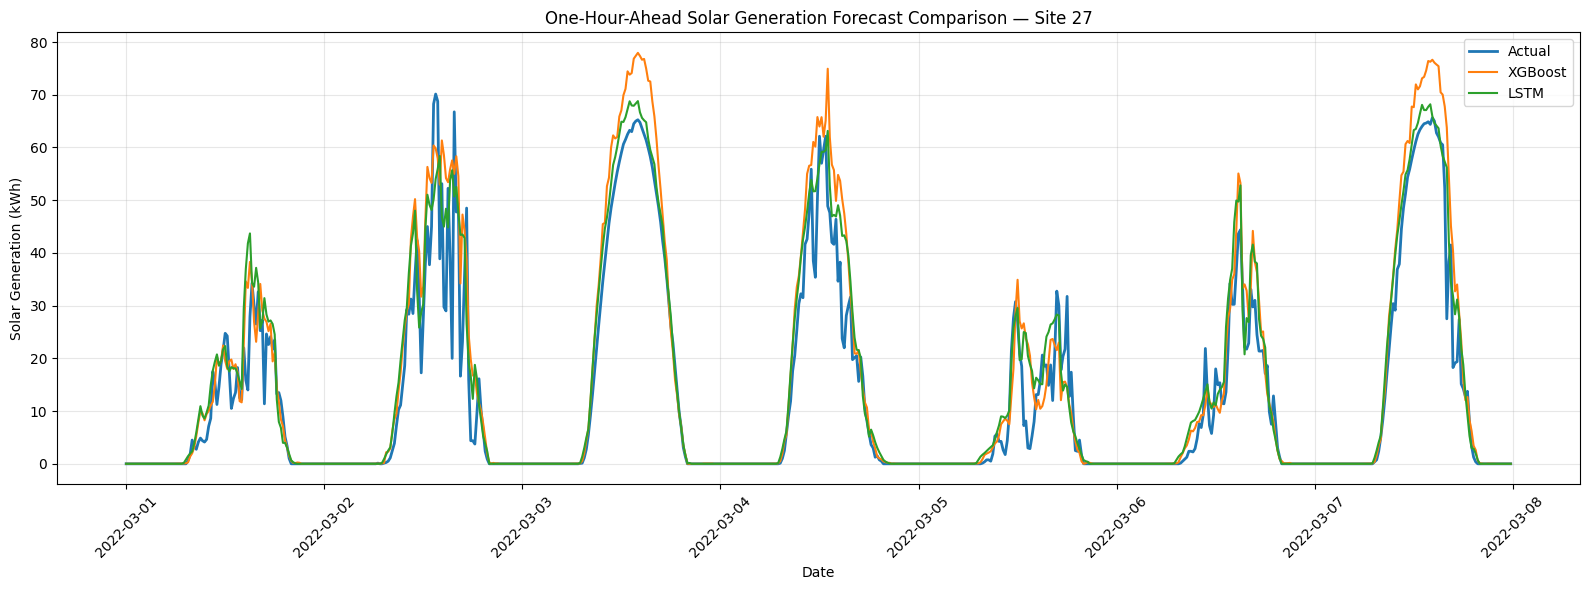

In [ ]:
site27_compare = forecast_compare[
    (forecast_compare['SiteKey'] == 27) &
    (forecast_compare['ForecastTime'] >= '2022-03-01') &
    (forecast_compare['ForecastTime'] < '2022-03-08')
].copy()

plt.figure(figsize=(16, 6))

plt.plot(
    site27_compare['ForecastTime'],
    site27_compare['Actual'],
    label='Actual',
    linewidth=2
)

plt.plot(
    site27_compare['ForecastTime'],
    site27_compare['XGBoost'],
    label='XGBoost',
    linewidth=1.5
)

plt.plot(
    site27_compare['ForecastTime'],
    site27_compare['LSTM'],
    label='LSTM',
    linewidth=1.5
)

plt.xlabel('Date')
plt.ylabel('Solar Generation (kWh)')
plt.title(
    'One-Hour-Ahead Solar Generation Forecast Comparison — Site 27'
)

plt.legend()
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 8.1 Improvement Over Persistence

The final comparison quantifies how much each machine-learning model reduces MAE and RMSE relative to the persistence baseline.


In [ ]:
# Build the final comparison directly from the stored test results rather than hard-coding metrics.
comparison = pd.DataFrame({
    'Model': test_results.index,
    'MAE': test_results['MAE (Overall)'].astype(float).values,
    'RMSE': test_results['RMSE (Overall)'].astype(float).values,
    'R²': test_results['R² (Overall)'].astype(float).values
})

persistence_mae = comparison.loc[
    comparison['Model'] == 'Persistence', 'MAE'
].iloc[0]

persistence_rmse = comparison.loc[
    comparison['Model'] == 'Persistence', 'RMSE'
].iloc[0]

comparison['MAE Improvement vs Persistence (%)'] = (
    (persistence_mae - comparison['MAE'])
    / persistence_mae
    * 100
)

comparison['RMSE Improvement vs Persistence (%)'] = (
    (persistence_rmse - comparison['RMSE'])
    / persistence_rmse
    * 100
)

comparison.round(2)


,Model,MAE,RMSE,R²,MAE Improvement vs Persistence (%),RMSE Improvement vs Persistence (%)
0,Persistence,1.46,3.82,0.83,0.00,0.00
1,XGBoost,0.62,1.99,0.95,57.95,48.01
2,LSTM,0.62,1.84,0.96,57.67,51.78


## 9. Conclusions and Limitations

Both machine-learning approaches substantially outperform the persistence baseline for one-hour-ahead PV generation forecasting. XGBoost achieves the lowest MAE, while the LSTM achieves the lowest RMSE and highest R². The same general pattern is retained during active-generation periods, indicating that the results are not driven only by easy nighttime zero-generation observations.

The two models capture temporal information differently: XGBoost relies on explicitly engineered historical lags, whereas the LSTM learns from a three-hour observation sequence. XGBoost therefore offers a strong accuracy-to-complexity trade-off, while the LSTM provides a modest advantage when larger forecast errors are penalized more strongly through RMSE.

A key limitation is that the models use historical generation and contemporaneous meteorological observations rather than future numerical weather predictions. Sudden irradiance changes within the one-hour forecast horizon may therefore be difficult to anticipate. In addition, site-level normalized MAE uses maximum observed generation because rated PV capacities are not available as modelling inputs.

Future work could evaluate numerical weather forecast inputs, probabilistic prediction intervals, and additional forecast horizons.


## References
**[1]** S. Wimalaratne, D. Haputhanthri, S. Kahawala, G. Gamage, D. Alahakoon, and A. Jennings, "UNISOLAR: An Open Dataset of Photovoltaic Solar Energy Generation in a Large Multi-Campus University Setting," *2022 15th International Conference on Human System Interaction (HSI)*, 2022, pp. 1–5, doi: [10.1109/HSI55341.2022.9869474](https://doi.org/10.1109/HSI55341.2022.9869474).